In [1]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.api import VAR

import yaml 

import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [8]:
df_merged = pd.read_csv("dataset_forecast_revenues_merged.csv")
df_merged["date"] = pd.to_datetime(df_merged["date"], format='ISO8601' )
df_merged = df_merged[df_merged['date']<='2026-01-01'] # I filter only where I have rows without null values

In [10]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 157 entries, 0 to 156
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Anno                        157 non-null    int64         
 1   Mese                        157 non-null    int64         
 2   TotSales                    157 non-null    float64       
 3   GDPGrowth                   157 non-null    float64       
 4   WorkingDays                 157 non-null    int64         
 5   date                        157 non-null    datetime64[ns]
 6   fixed_term                  157 non-null    float64       
 7   permanent                   157 non-null    float64       
 8   workforce                   157 non-null    float64       
 9   inactives                   157 non-null    float64       
 10  employment_rate             157 non-null    float64       
 11  youth_employment_rate       157 non-null    float64       
 12 

In [11]:
meadian_comp_trust= df_merged['companies_trust'].median()
meadian_ind_price = df_merged['industry_production_prices'].median()
df_merged['companies_trust'] = df_merged['companies_trust'].fillna(meadian_comp_trust )
df_merged['industry_production_prices'] = df_merged['industry_production_prices'].fillna(meadian_ind_price )

In [12]:
df_merged = df_merged[['Anno', 'Mese','date', 'GDPGrowth', 'WorkingDays', 
                        'fixed_term', 'permanent', 'workforce', 'inactives', 'employment_rate',
                        'youth_employment_rate', 'activity_rate', 'unemployment_rate',
                        'industry_production_prices', 'companies_trust', 'gasoline_car_price',
                        'diesel_price', 'GPL_price', 'diesel_heatining_price', 'TotSales']]

# 1. Data Exploration

In [13]:
df_merged[['fixed_term', 'permanent', 'workforce', 'inactives']] = df_merged[['fixed_term', 'permanent', 'workforce', 'inactives']]*1000

df_merged[['fixed_term', 'permanent', 'workforce', 'inactives', 'TotSales']] = df_merged[['fixed_term', 'permanent', 'workforce', 'inactives', 'TotSales']].astype(int)

In [14]:
df_merged.head(5).style


,Anno,Mese,date,GDPGrowth,WorkingDays,fixed_term,permanent,workforce,inactives,employment_rate,youth_employment_rate,activity_rate,unemployment_rate,industry_production_prices,companies_trust,gasoline_car_price,diesel_price,GPL_price,diesel_heatining_price,TotSales
0,2013,1,2013-01-01 00:00:00,-2.940000,22,2075150,14350762,24545012,14461505,39.960000,54.540000,62.930000,13.320000,94.200000,77.700000,1.749940,1.694380,0.872030,1.439480,72281234
1,2013,2,2013-02-01 00:00:00,-2.681780,20,2095972,14194558,24651944,14350054,41.100000,54.820000,63.210000,13.270000,94.300000,76.600000,1.781000,1.699670,0.856760,1.456800,67838429
2,2013,3,2013-03-01 00:00:00,-2.425113,21,2215498,14155228,24585629,14412556,40.200000,54.940000,63.040000,12.860000,94.300000,78.100000,1.796910,1.693940,0.841490,1.431790,74458328
3,2013,4,2013-04-01 00:00:00,-2.170000,20,2127703,14369197,24489735,14505159,39.020000,54.780000,62.800000,12.780000,93.900000,74.200000,1.753800,1.651110,0.811660,1.404300,76523786
4,2013,5,2013-05-01 00:00:00,-1.916440,22,2192895,14252845,24531196,14459758,40.390000,55.040000,62.920000,12.510000,93.900000,75.900000,1.716160,1.612310,0.773740,1.375990,82679695


In [15]:
numeric = [  'GDPGrowth', 'WorkingDays', 
            'fixed_term', 'permanent', 'workforce', 'inactives', 'employment_rate',
            'youth_employment_rate', 'activity_rate', 'unemployment_rate',
            'industry_production_prices', 'companies_trust', 'gasoline_car_price',
            'diesel_price', 'GPL_price', 'diesel_heatining_price', 'TotSales', "date"]

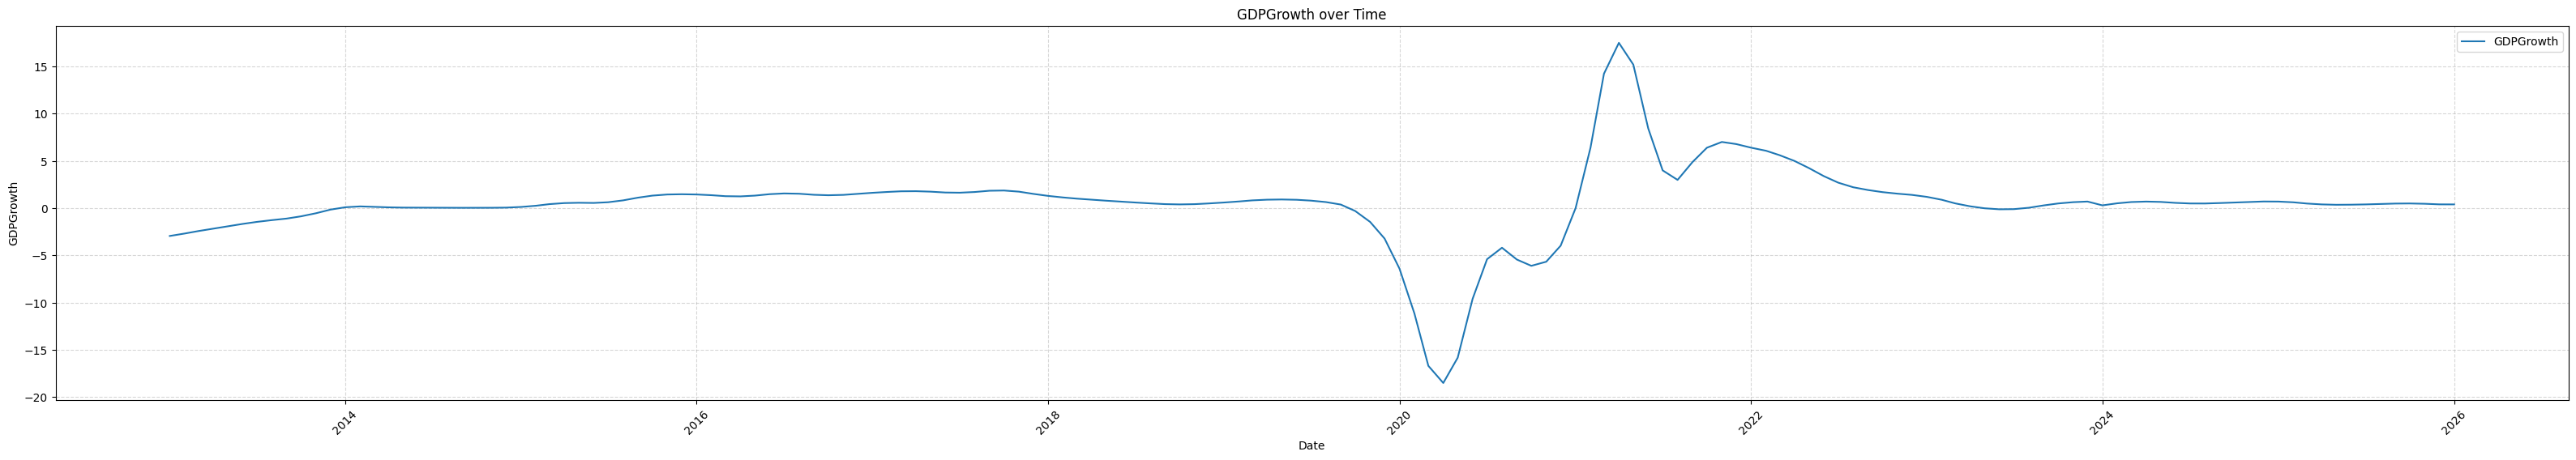

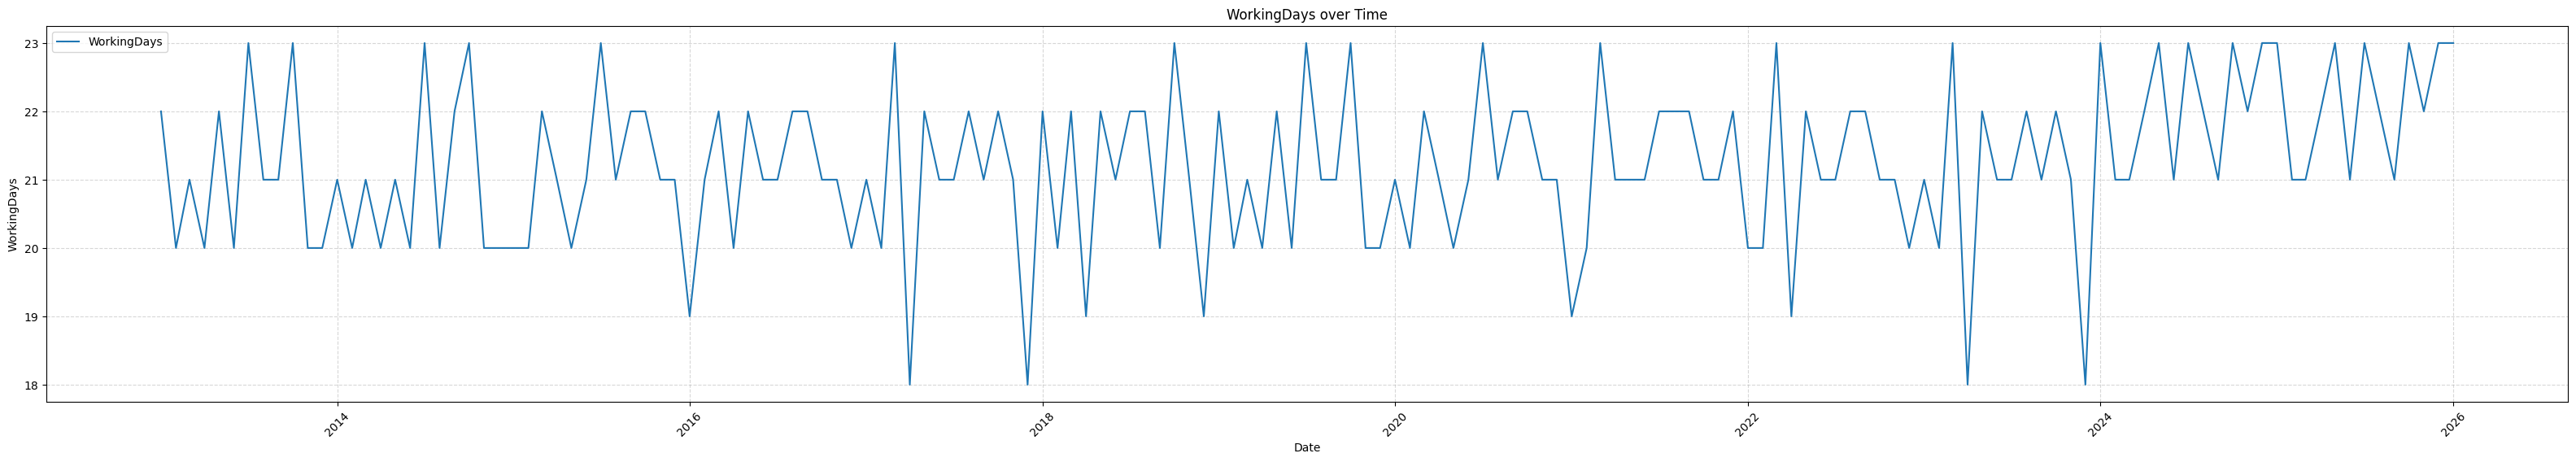

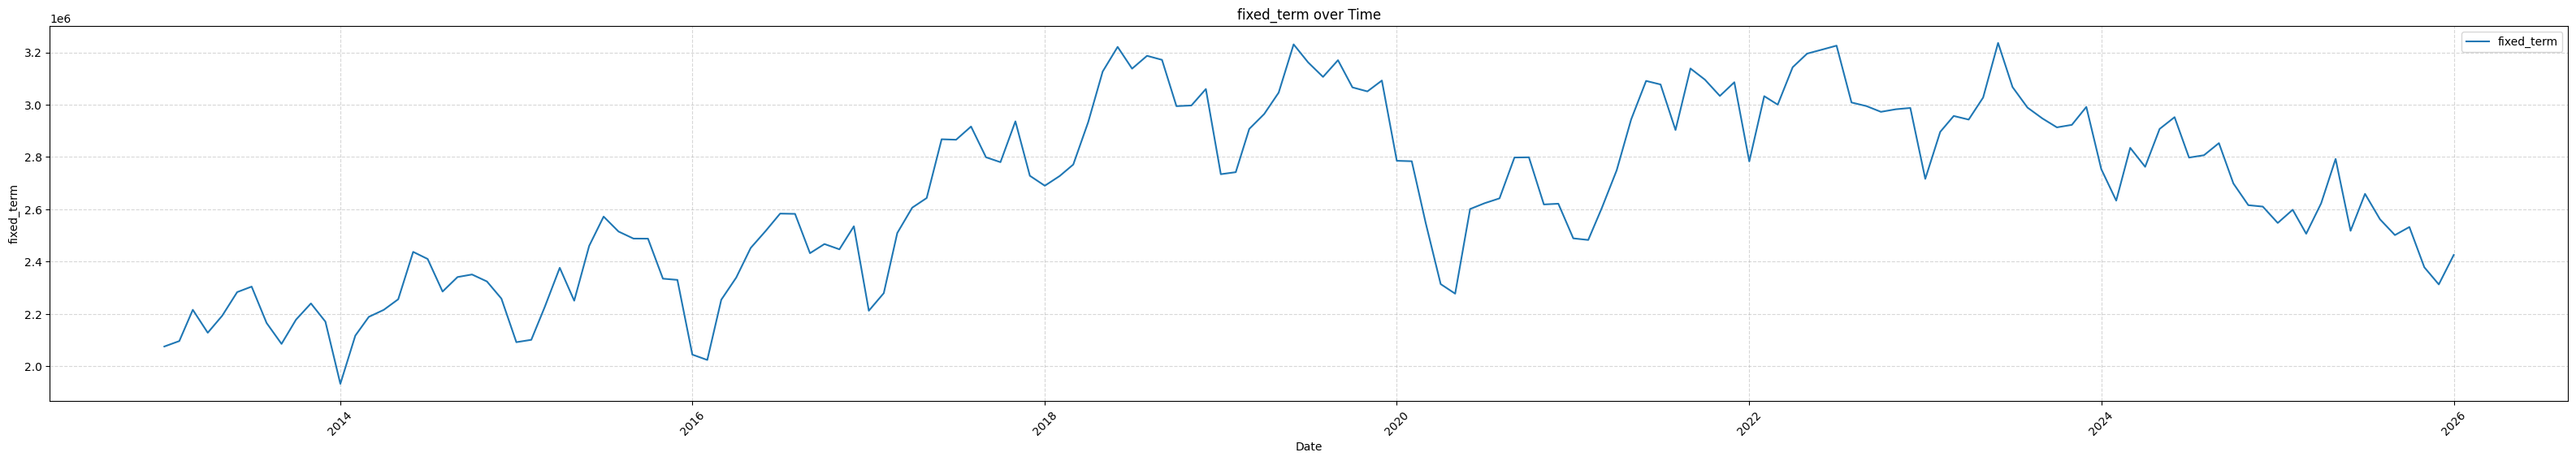

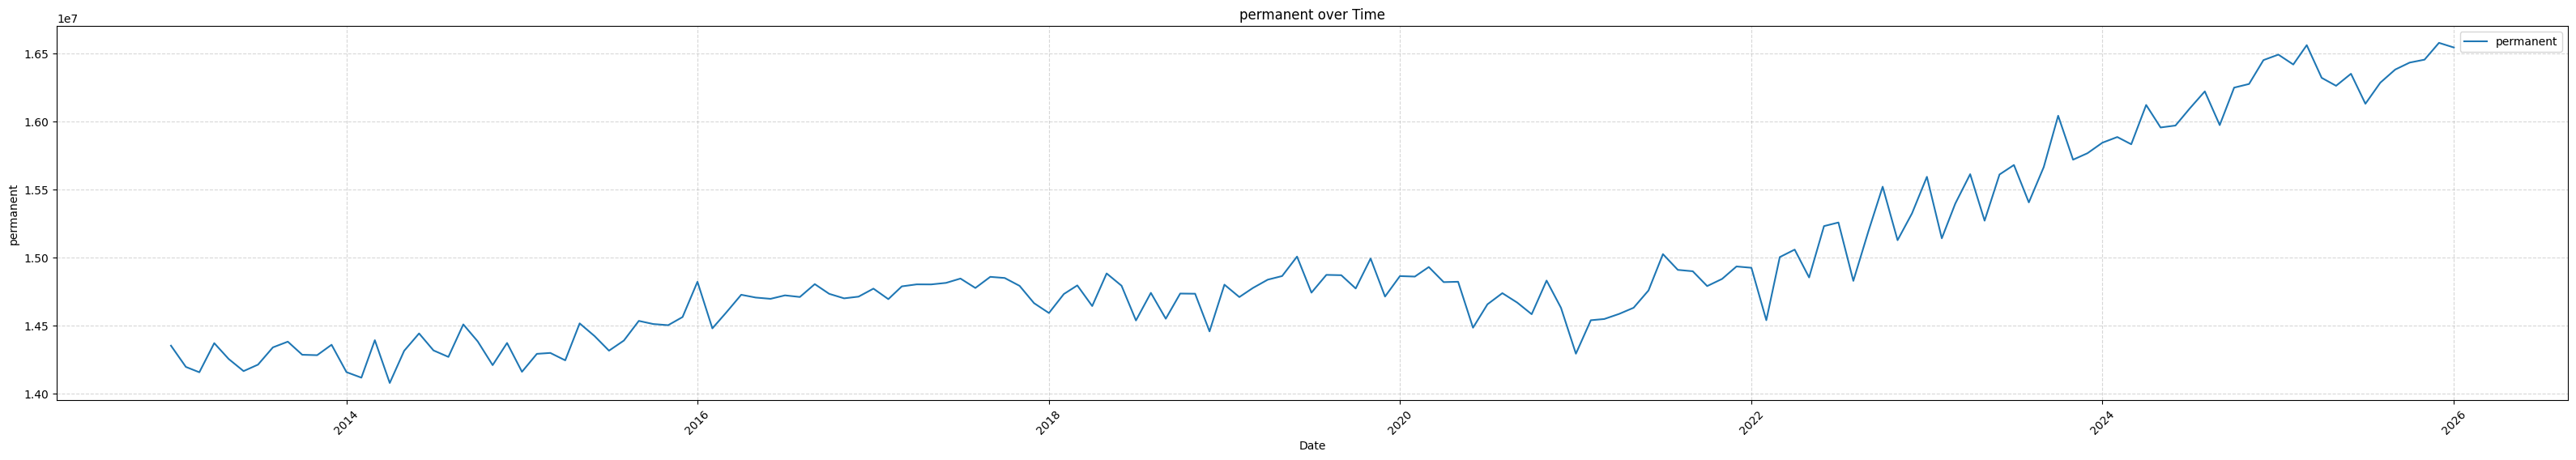

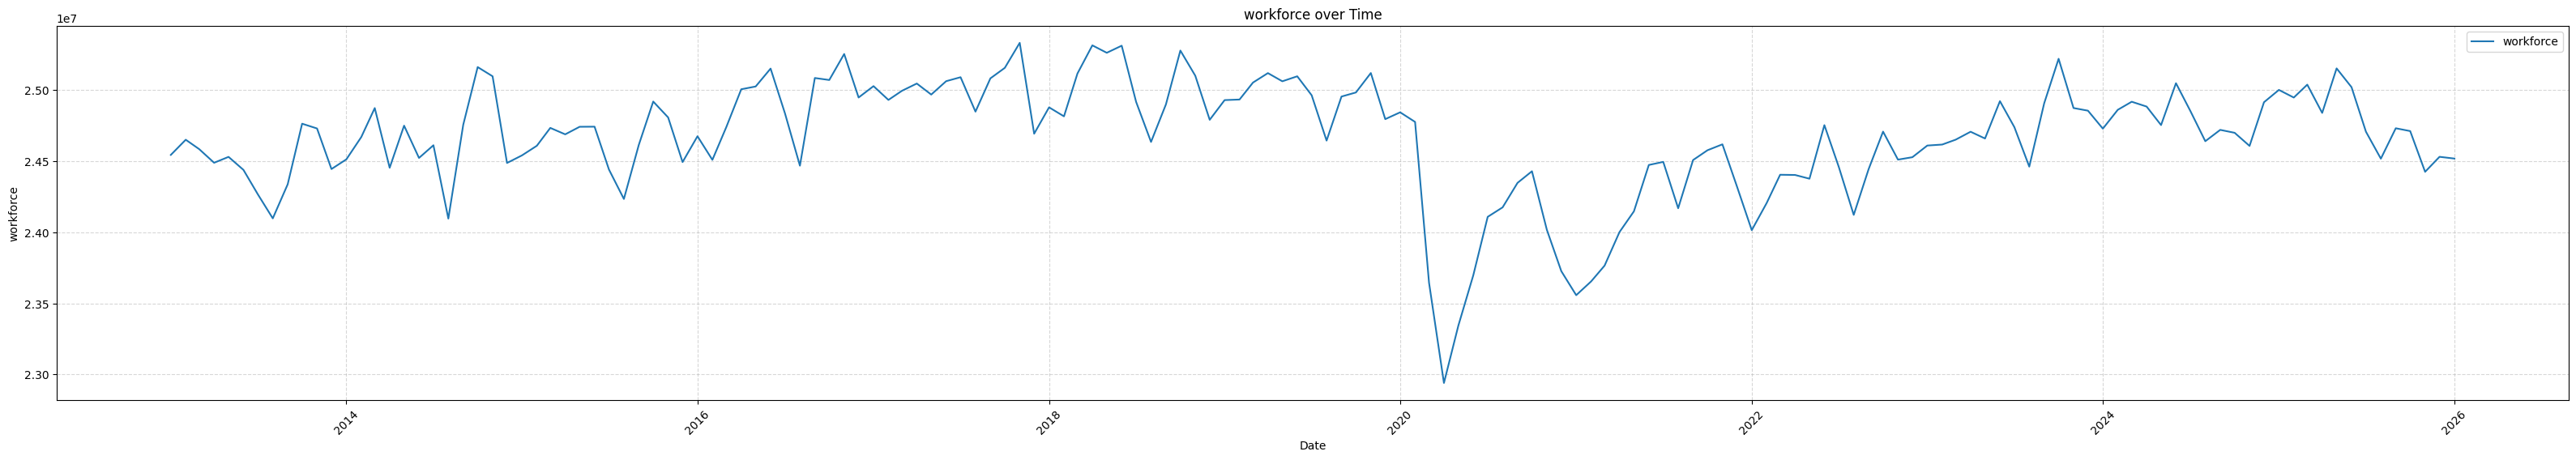

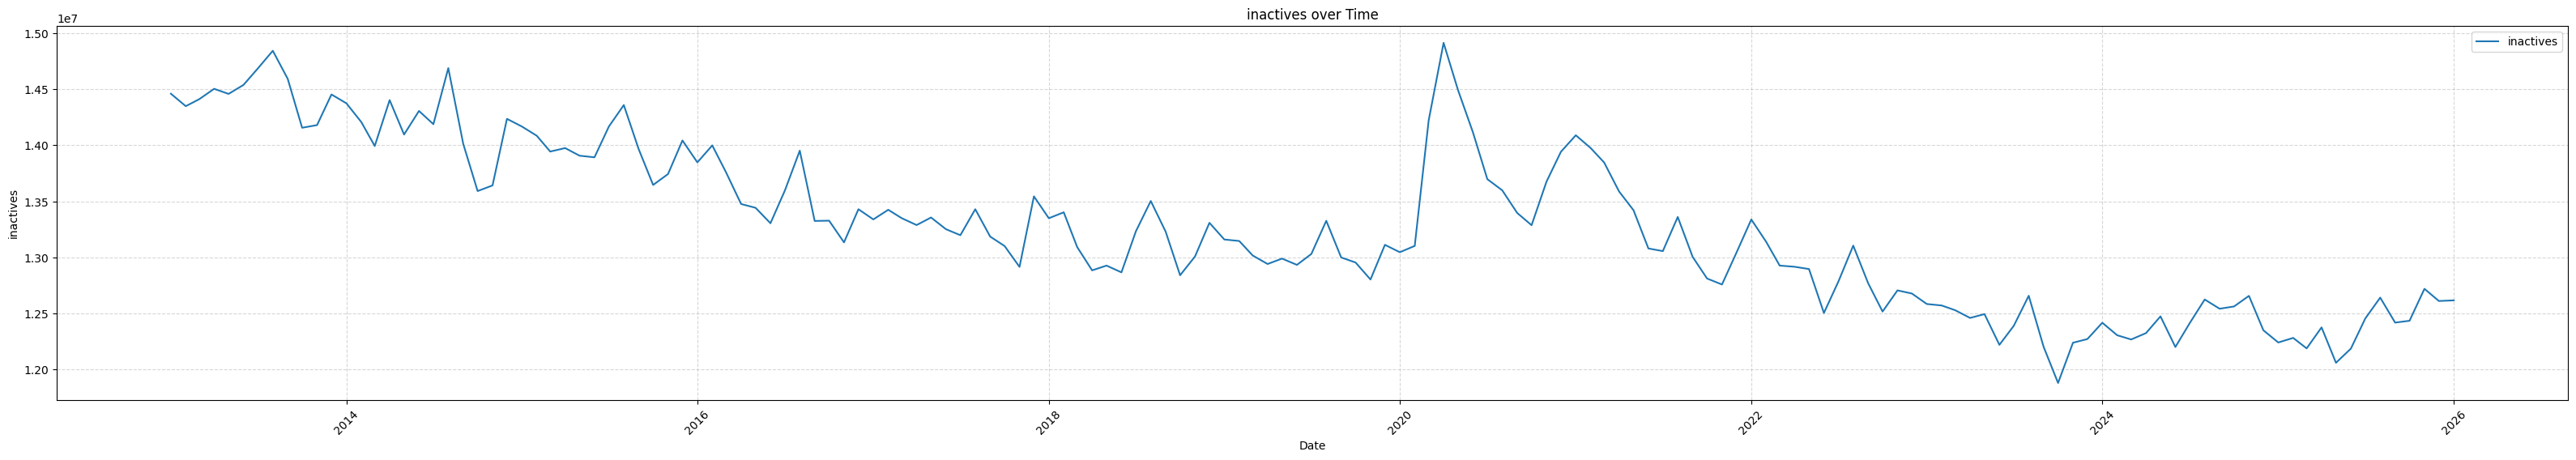

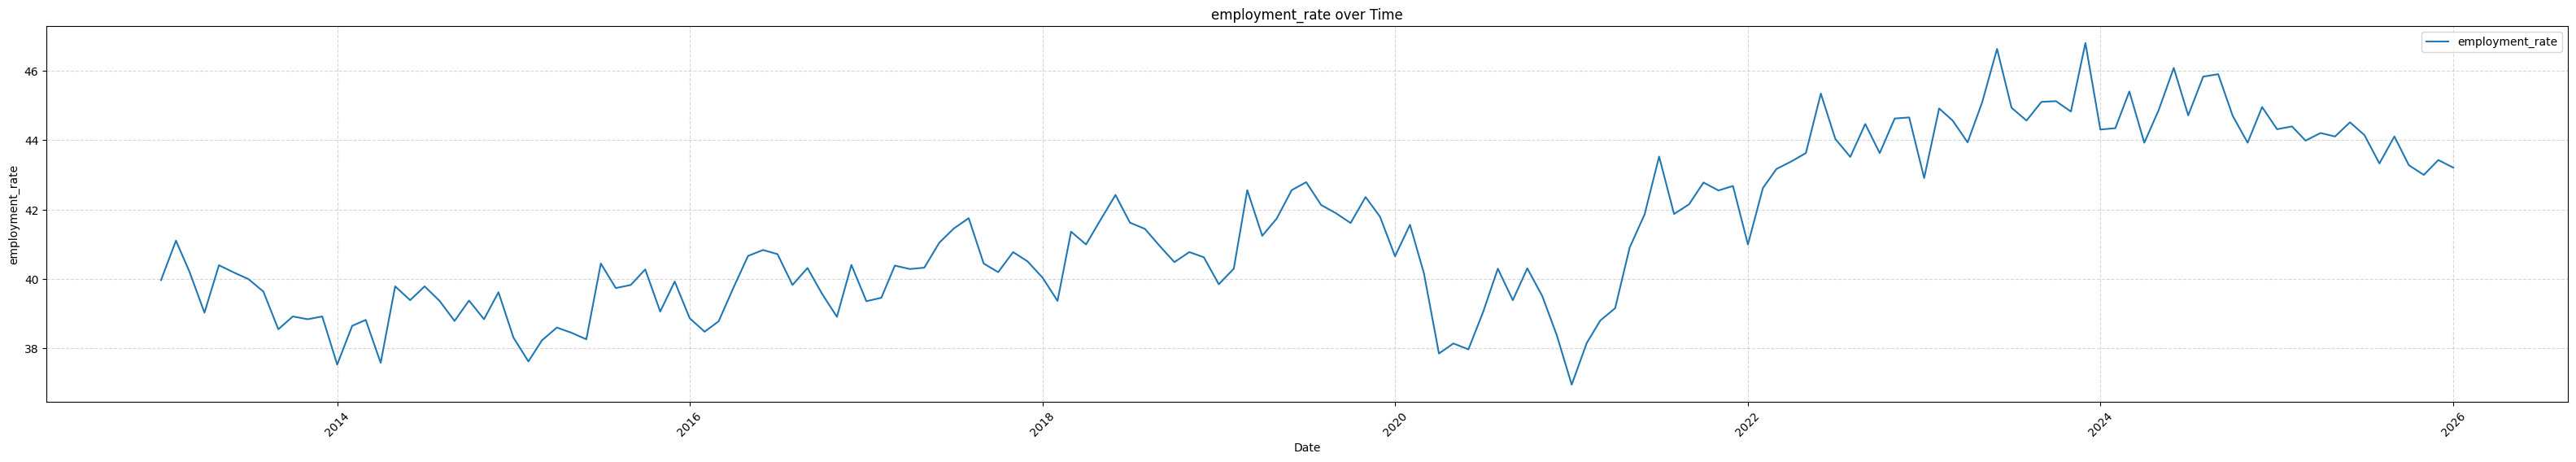

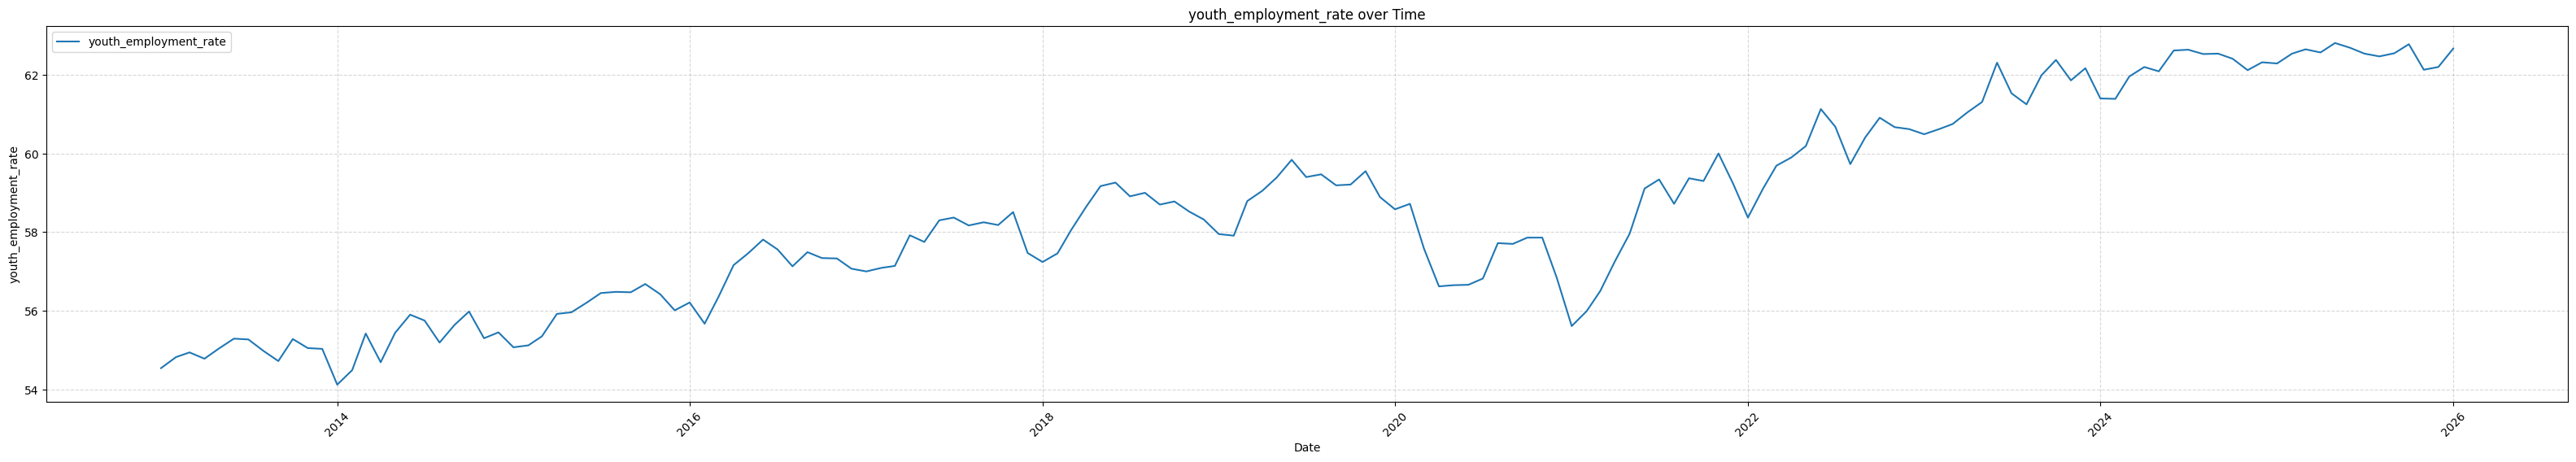

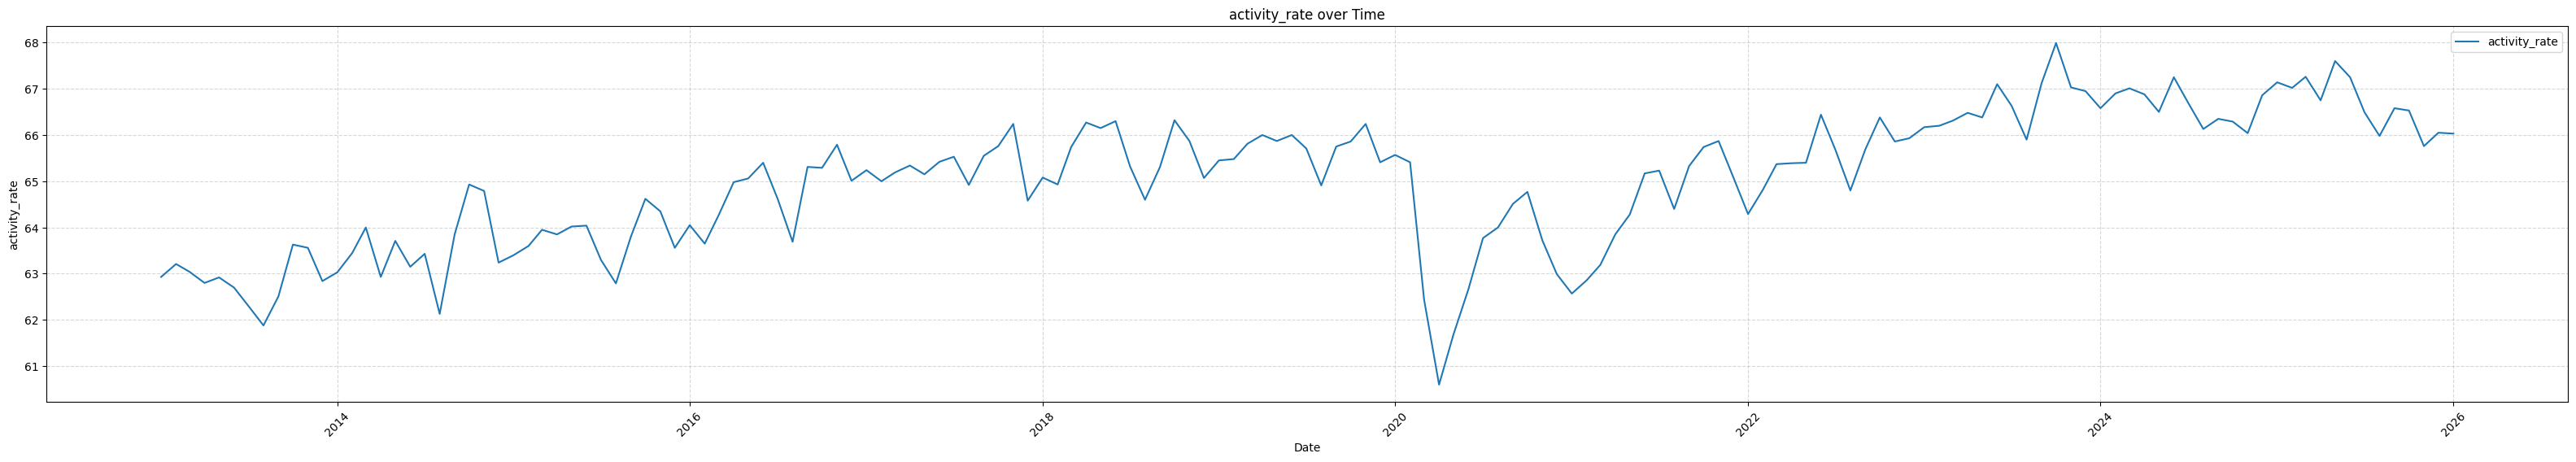

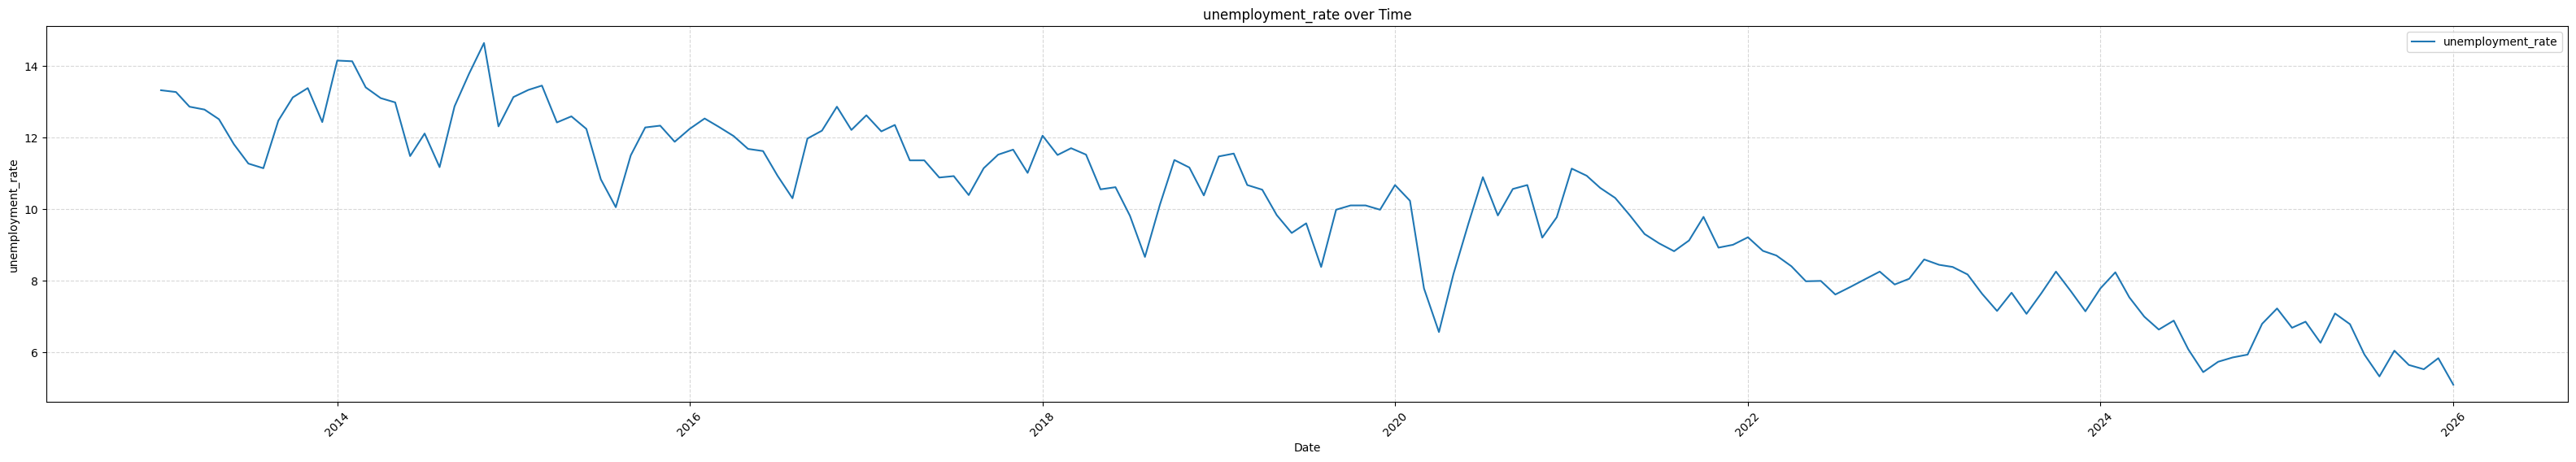

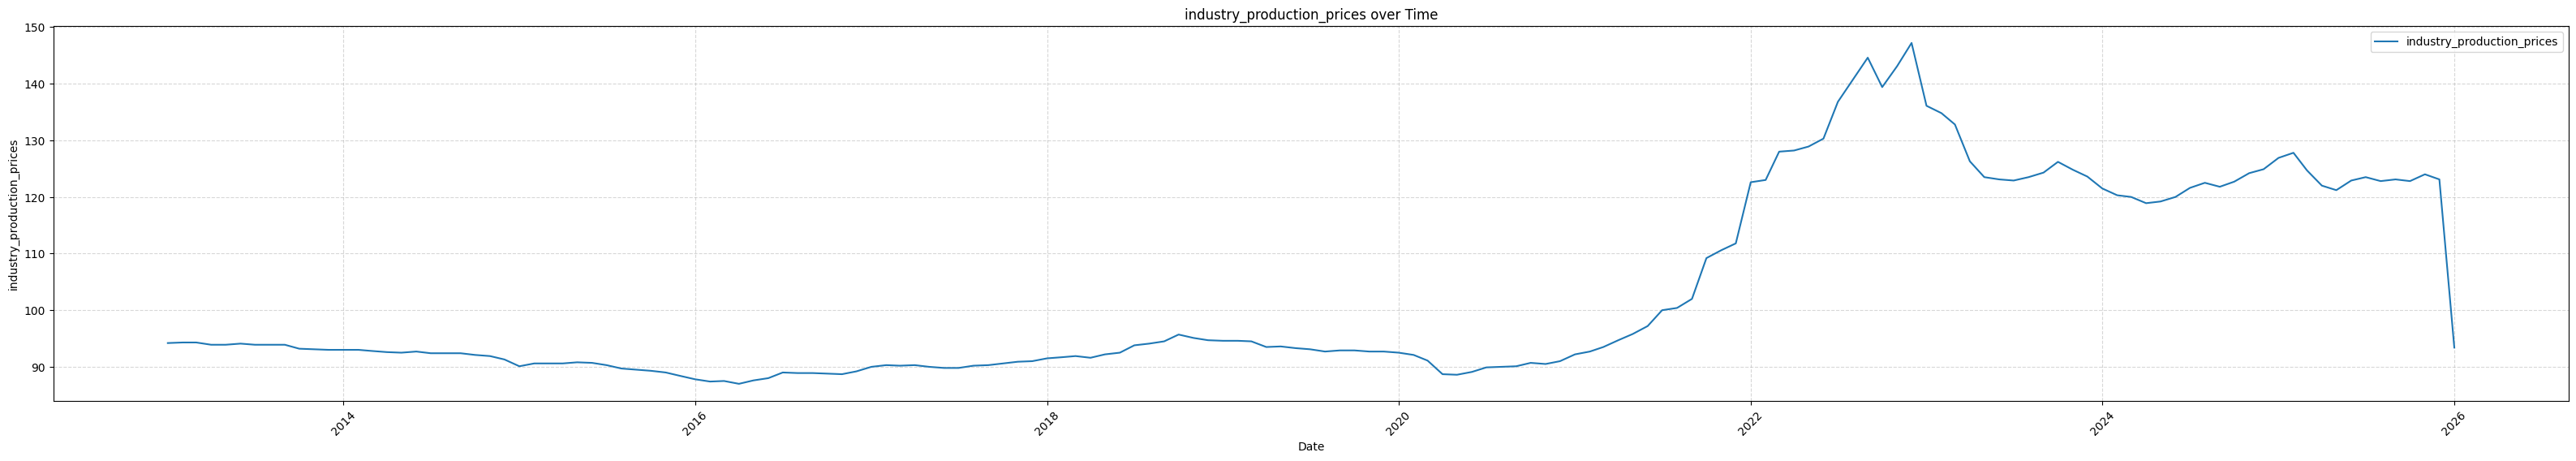

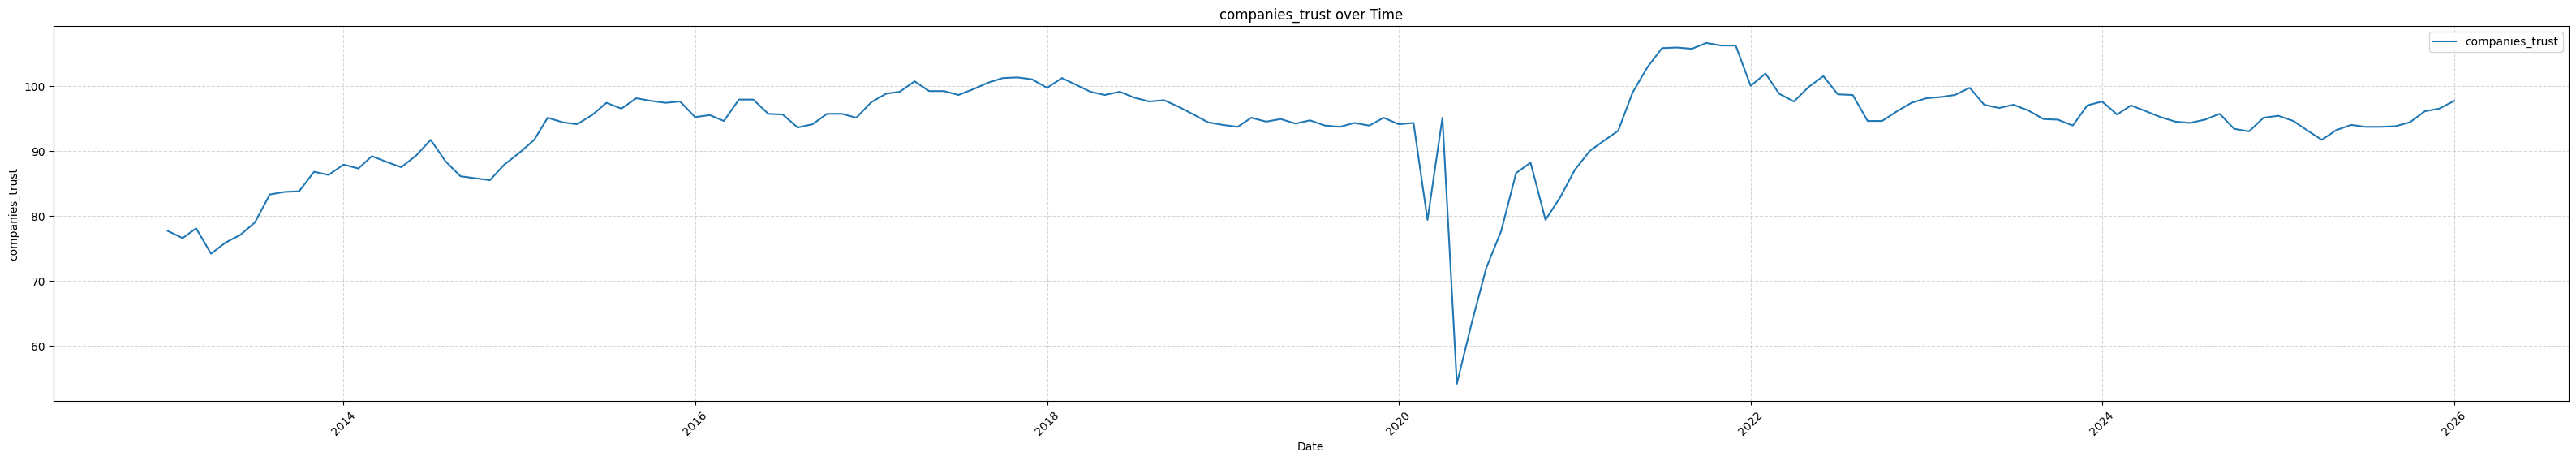

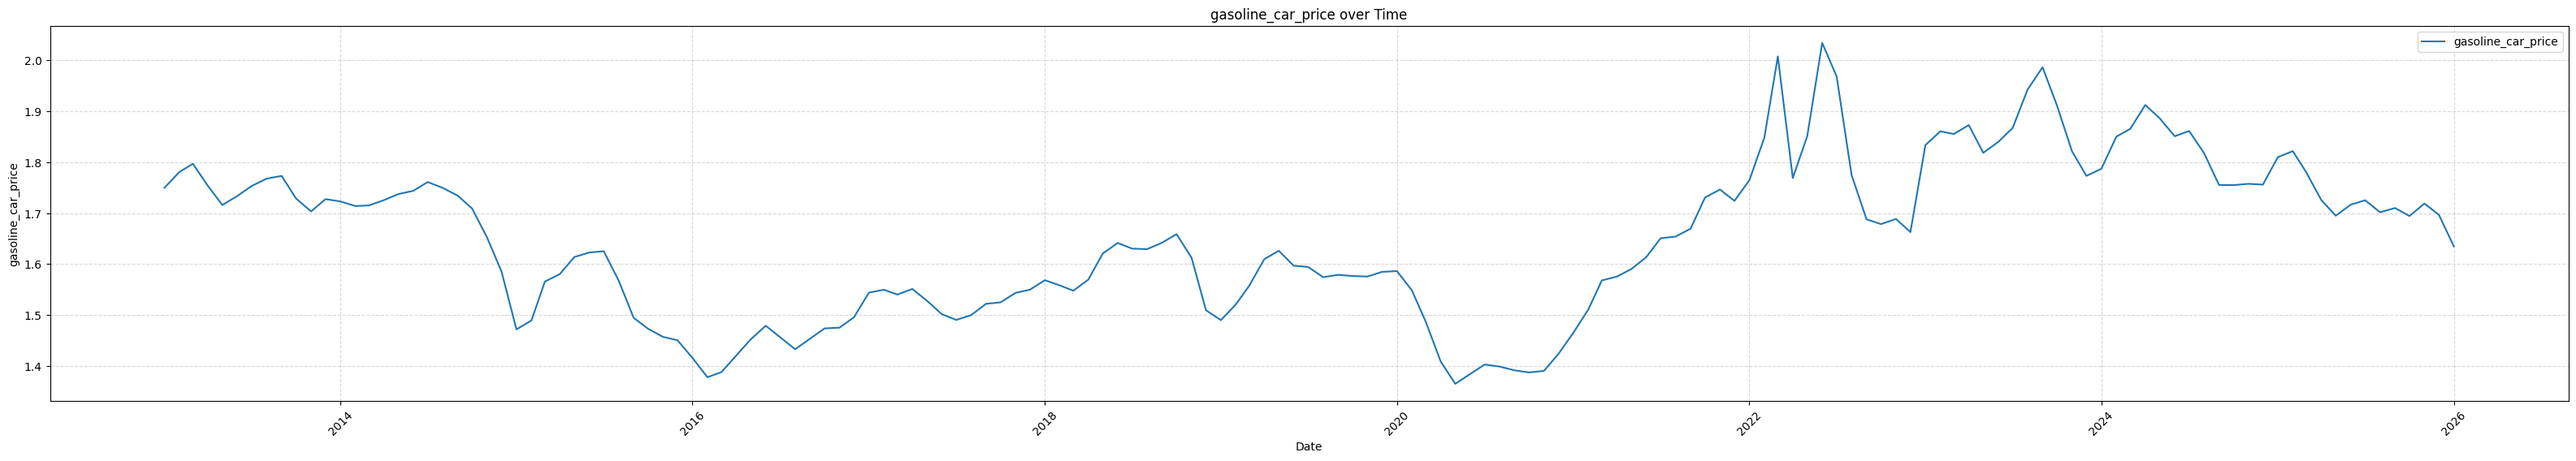

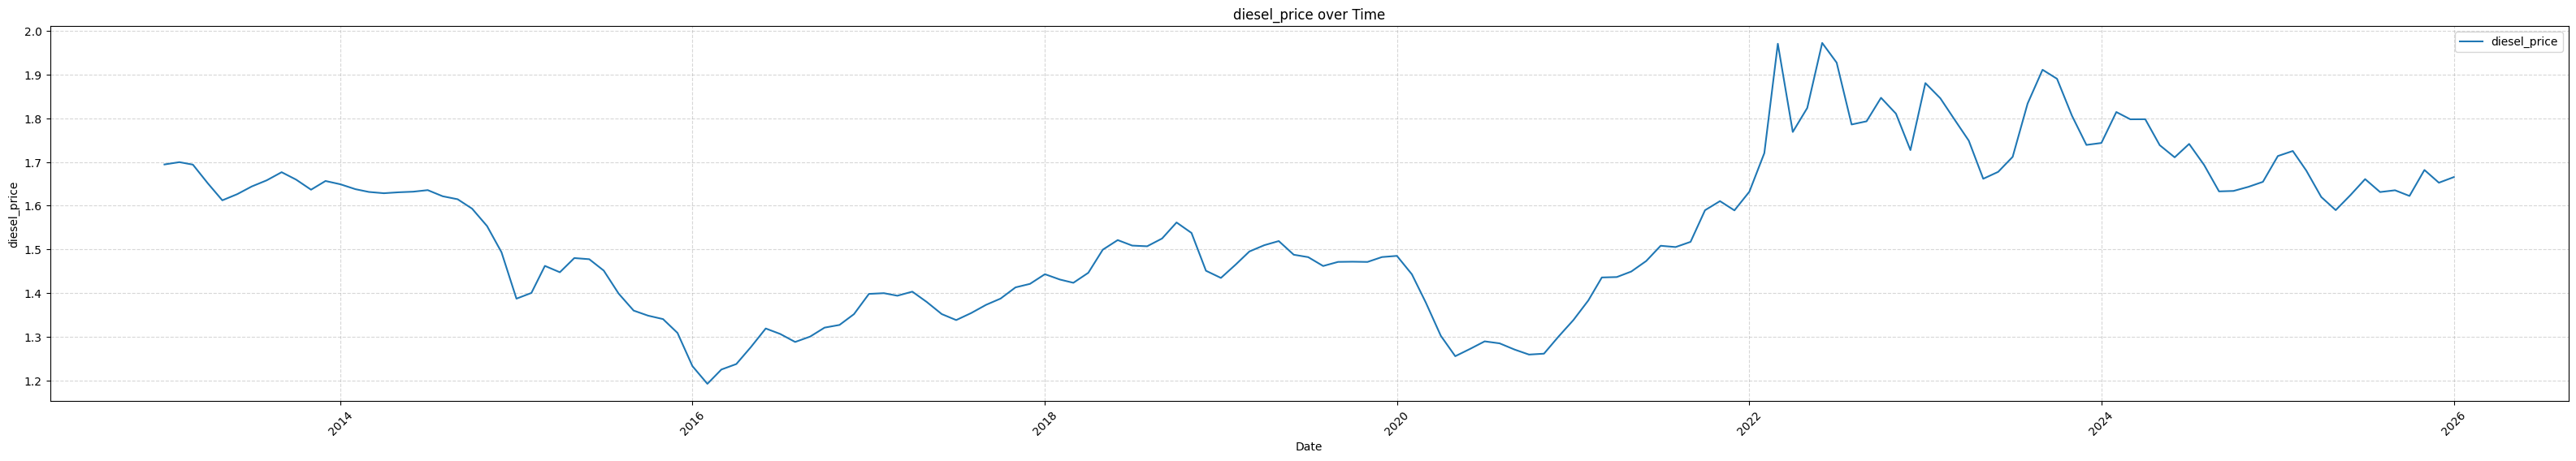

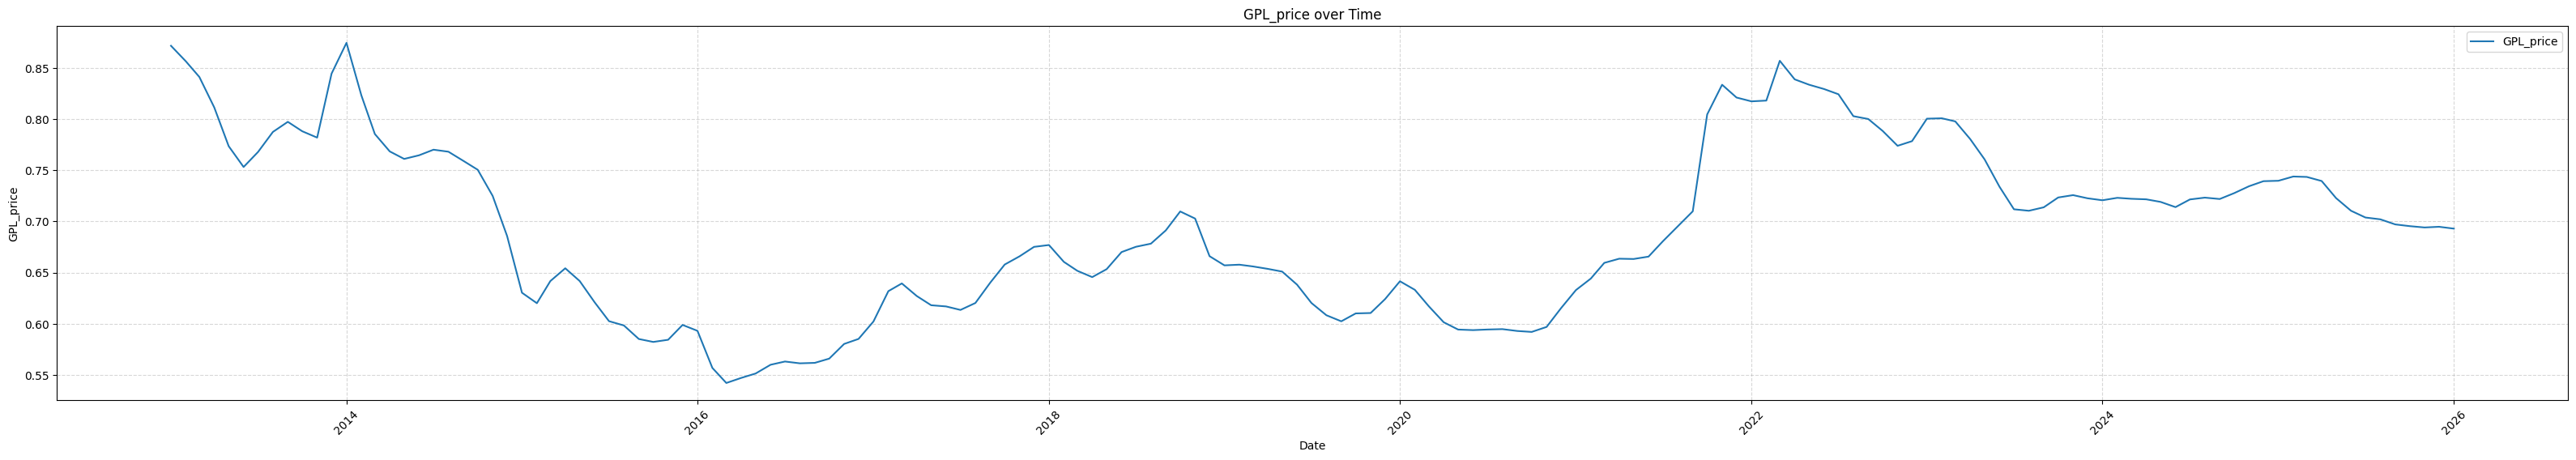

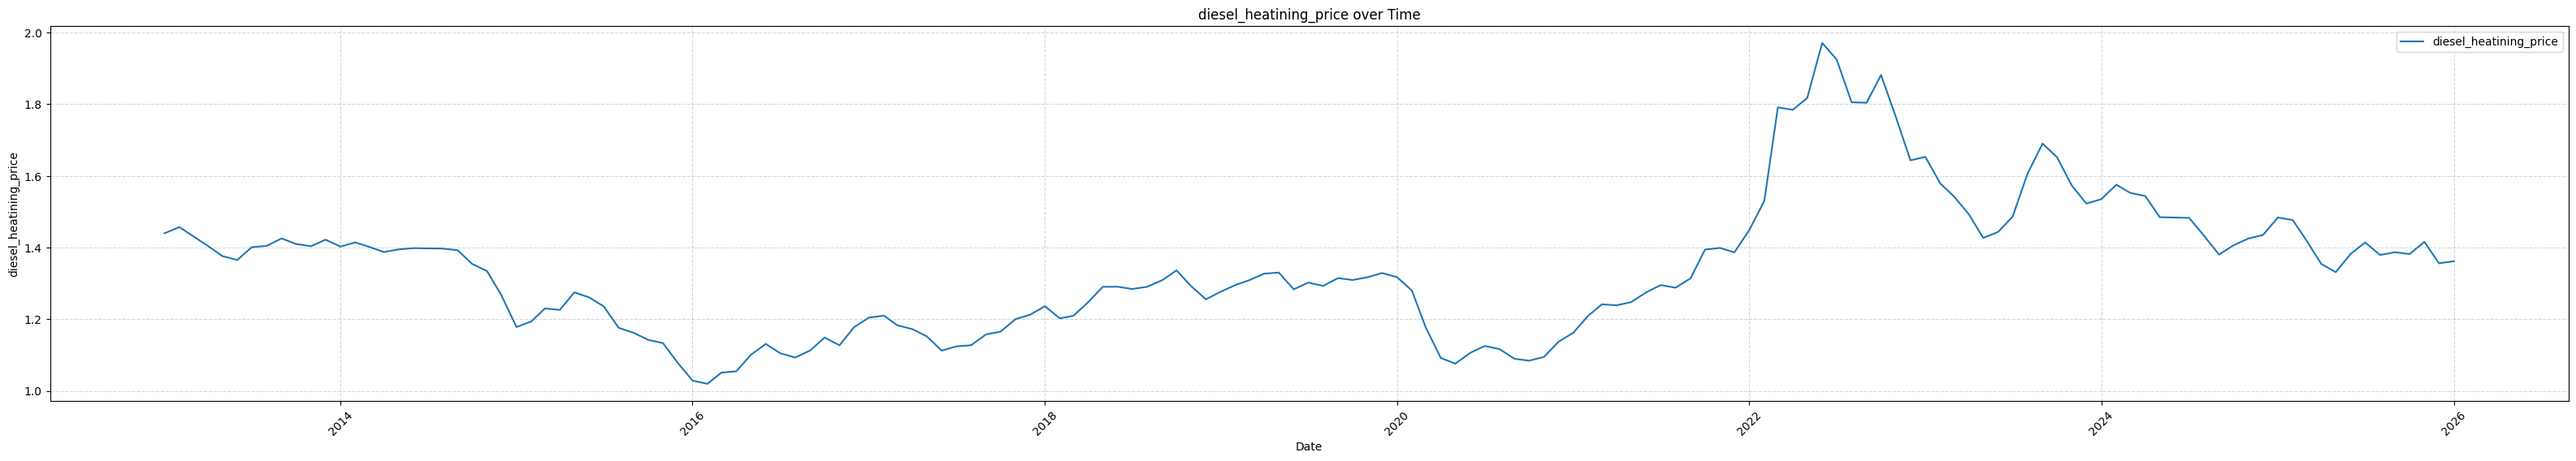

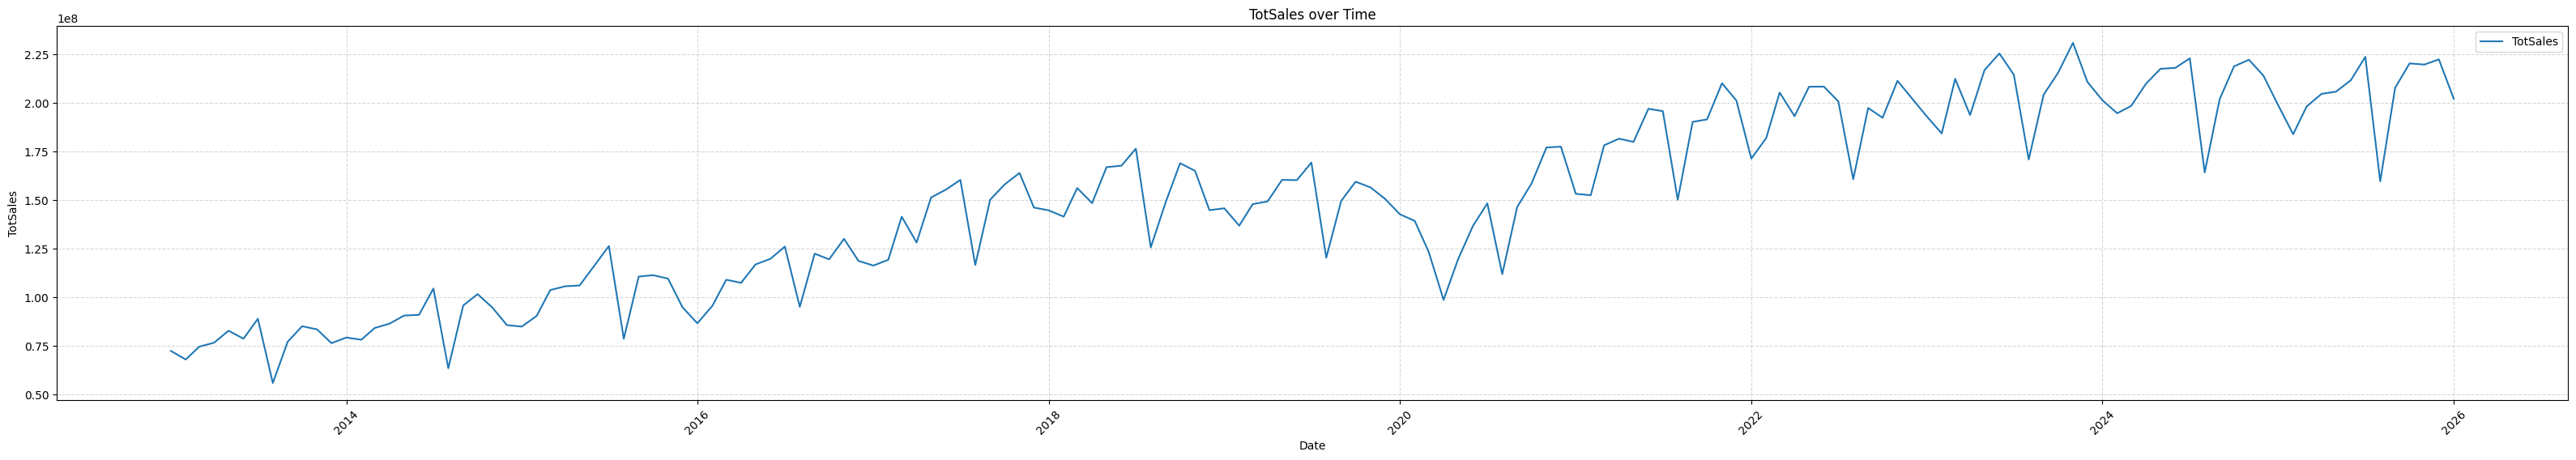

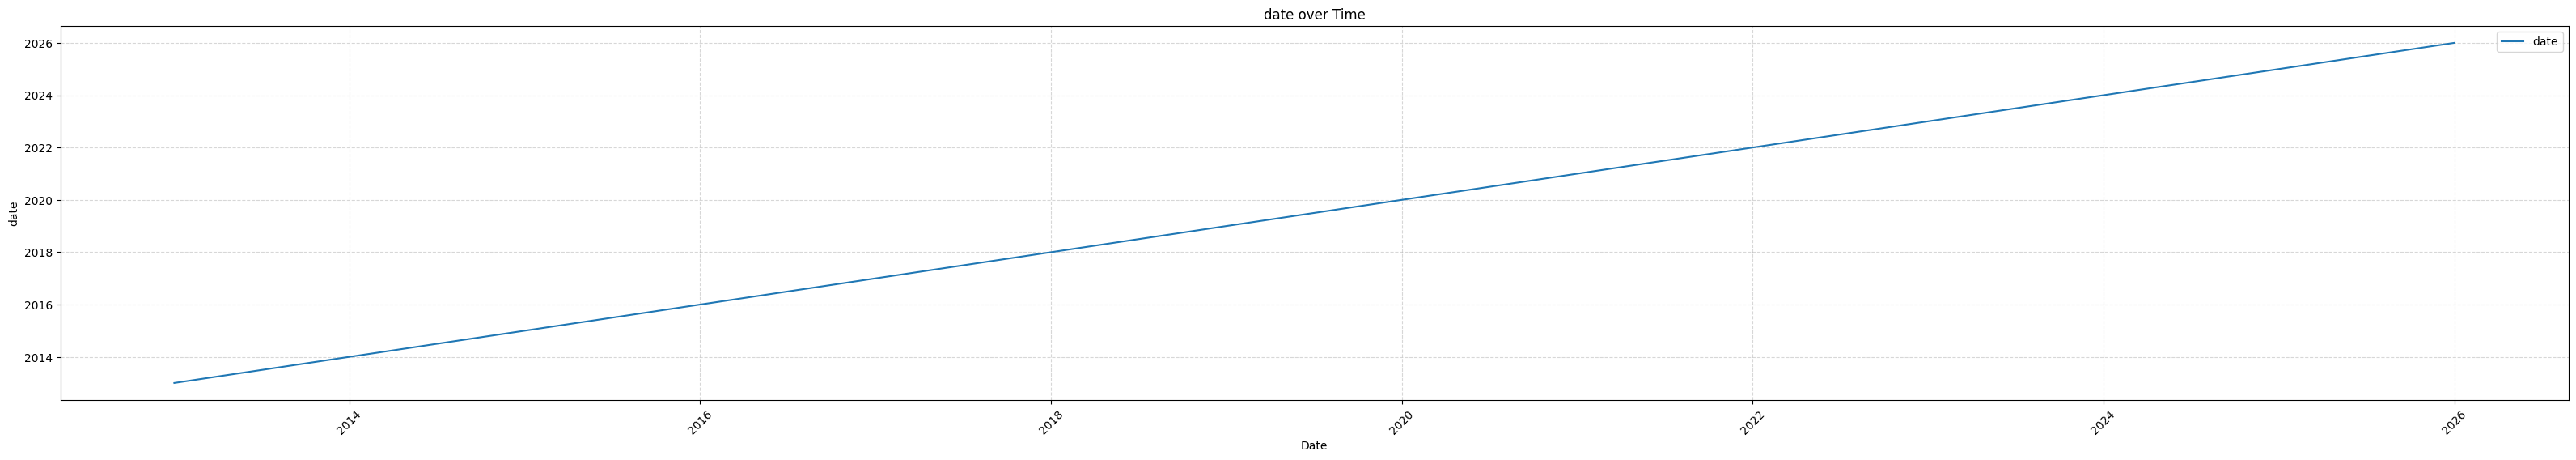

In [16]:
import matplotlib.dates as mdates

for col in numeric:
    plt.figure(figsize=(40, 6))
    
    # Create lineplot
    sns.lineplot(data=df_merged, x='date', y=col, label = col)
 
    plt.xticks(rotation=45)
    
    # Add title and labels
    plt.title(f'{col} over Time')
    plt.xlabel('Date')
 
    plt.grid(True, linestyle='--', alpha=0.5)
 
    plt.show()

## 1.1.1 Features creation

In [17]:
df_merged['covid_period'] = ((df_merged['date']>= pd.Timestamp('2020-03-01')) &
                              (df_merged['date']<= pd.Timestamp('2021-05-31'))).astype(int)

df_merged['ukraine_war'] = (df_merged['date']> pd.Timestamp('2022-02-01')).astype(int)

## 1.2 ADF test: looking for stationarity

In [18]:
numeric_cols  =['GDPGrowth', 'WorkingDays', 'fixed_term',
                    'permanent', 'workforce', 'inactives', 'employment_rate',
                    'youth_employment_rate', 'activity_rate', 'unemployment_rate',
                    'industry_production_prices', 'companies_trust', 'gasoline_car_price',
                    'diesel_price', 'GPL_price', 'diesel_heatining_price', 'TotSales']

In [19]:
stationary_cols = []
non_stationary_cols = []

for col in numeric_cols:
    print('---------------------------------------------')
    print(col)
    print('---------------------------------------------')

    test_staticist = adfuller(df_merged[col])[0]
    adf_criticatical_value_5perc = adfuller(df_merged[col])[4]['5%']
    if test_staticist > adf_criticatical_value_5perc:
        non_stationary_cols.append(col)
        print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
        df_merged[f'{col}_diff'] = df_merged[col] - df_merged[col].shift( 1) # qui facciamo subito la differnziazione

    else:
        stationary_cols.append(col)
        print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')

---------------------------------------------
GDPGrowth
---------------------------------------------
-3.63 < -2.88 ==> The time series is STATIONARY
---------------------------------------------
WorkingDays
---------------------------------------------
0.69 > -2.88 ==> The time series is NON stationary
---------------------------------------------
fixed_term
---------------------------------------------
-2.3 > -2.88 ==> The time series is NON stationary
---------------------------------------------
permanent
---------------------------------------------
1.38 > -2.88 ==> The time series is NON stationary
---------------------------------------------
workforce
---------------------------------------------
-2.58 > -2.88 ==> The time series is NON stationary
---------------------------------------------
inactives
---------------------------------------------
-1.93 > -2.88 ==> The time series is NON stationary
---------------------------------------------
employment_rate
------------------

In [20]:
stationary_cols

['GDPGrowth', 'companies_trust', 'GPL_price']

In [21]:
non_stationary_cols

['WorkingDays',
 'fixed_term',
 'permanent',
 'workforce',
 'inactives',
 'employment_rate',
 'youth_employment_rate',
 'activity_rate',
 'unemployment_rate',
 'industry_production_prices',
 'gasoline_car_price',
 'diesel_price',
 'diesel_heatining_price',
 'TotSales']

In [22]:
df_merged.columns

Index(['Anno', 'Mese', 'date', 'GDPGrowth', 'WorkingDays', 'fixed_term',
       'permanent', 'workforce', 'inactives', 'employment_rate',
       'youth_employment_rate', 'activity_rate', 'unemployment_rate',
       'industry_production_prices', 'companies_trust', 'gasoline_car_price',
       'diesel_price', 'GPL_price', 'diesel_heatining_price', 'TotSales',
       'covid_period', 'ukraine_war', 'WorkingDays_diff', 'fixed_term_diff',
       'permanent_diff', 'workforce_diff', 'inactives_diff',
       'employment_rate_diff', 'youth_employment_rate_diff',
       'activity_rate_diff', 'unemployment_rate_diff',
       'industry_production_prices_diff', 'gasoline_car_price_diff',
       'diesel_price_diff', 'diesel_heatining_price_diff', 'TotSales_diff'],
      dtype='object')

In [23]:
df_merged[['Anno', 'Mese', 'date'] + stationary_cols + non_stationary_cols].to_csv("dataset_FINAL_not_differentiated.csv", index = False)

# Differeziazione

In [24]:
non_stationary_cols = [
    #'WorkingDays', 
 'fixed_term',
 'permanent',
 'workforce',
 'inactives',
 'employment_rate',
 'youth_employment_rate',
 'activity_rate',
 'unemployment_rate',
 'industry_production_prices',
 'gasoline_car_price',
 'diesel_price',
 'diesel_heatining_price',
 'TotSales']

diff_cols=['fixed_term_diff', 'permanent_diff', 'workforce_diff',  'inactives_diff', 'employment_rate_diff', 'youth_employment_rate_diff',
 'activity_rate_diff', 'unemployment_rate_diff', 'industry_production_prices_diff', 'gasoline_car_price_diff', 'diesel_price_diff',
   'diesel_heatining_price_diff', 'TotSales_diff']

In [25]:
# df_merged[diff_cols] = df_merged[non_stationary_cols].diff()

In [26]:
df_merged_detrended =  df_merged[['Anno', 'Mese', 'date', 'GDPGrowth', 'WorkingDays',  
                                    'fixed_term_diff', 'permanent_diff', 'workforce_diff', 
                                    'inactives_diff', 'employment_rate_diff', 'youth_employment_rate_diff',
                                    'activity_rate_diff', 'unemployment_rate_diff', 'industry_production_prices_diff','companies_trust',  
                                    'gasoline_car_price_diff', 'diesel_price_diff',  'GPL_price',  'diesel_heatining_price_diff', 
                                    'covid_period', 'ukraine_war','TotSales_diff', 'TotSales']]

## 1.3 ACF and PACF plot

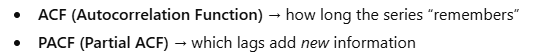

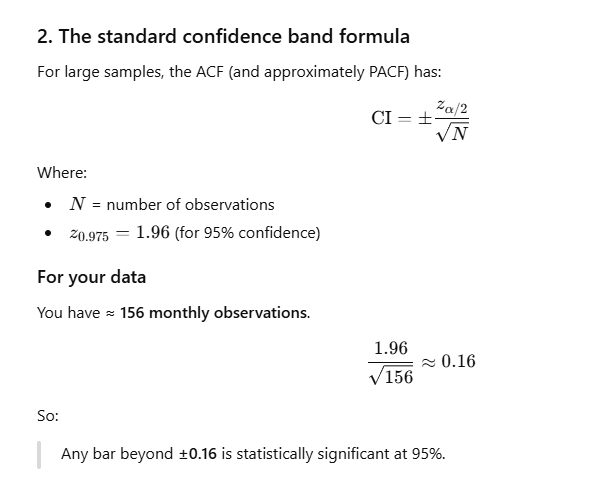

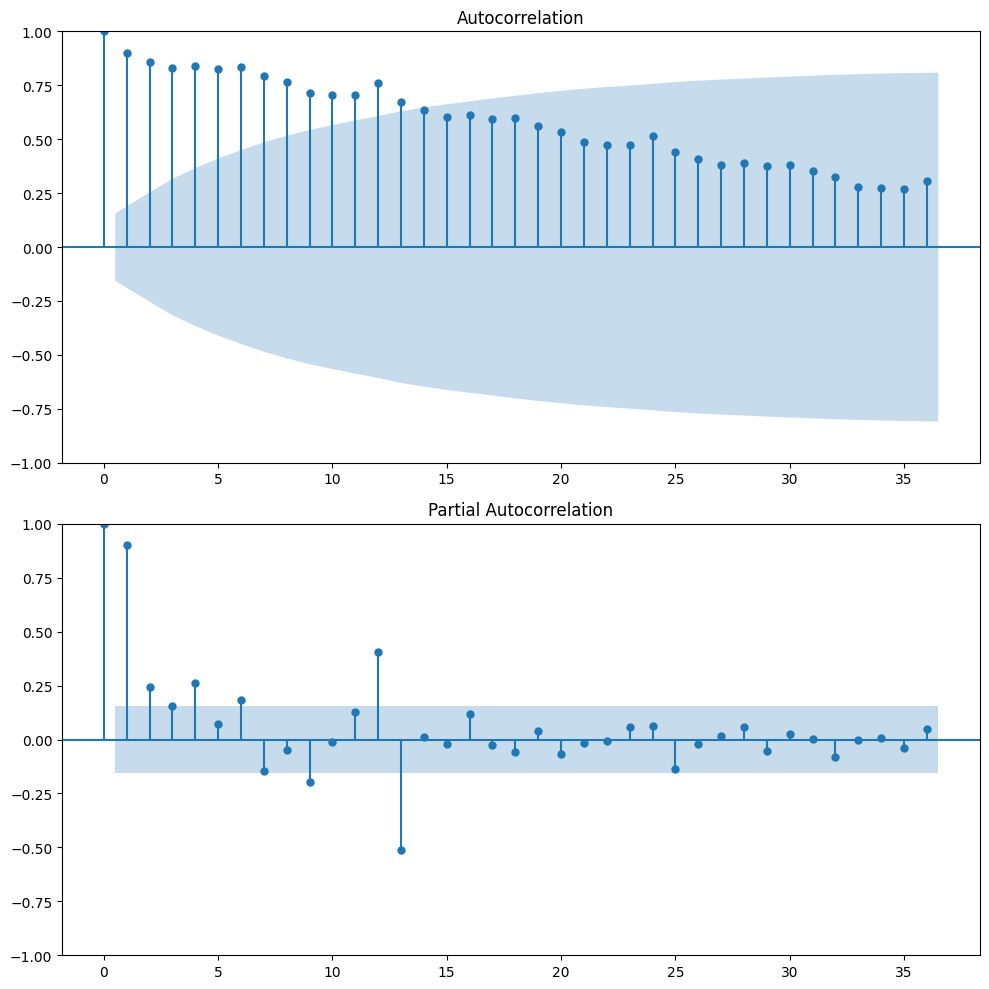

In [27]:
width = 10
height = 5

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2*height))
plot_acf(df_merged_detrended['TotSales'],lags=36, ax=ax[0], alpha=0.05 )
plot_pacf(df_merged_detrended['TotSales'],lags=36, ax=ax[1], alpha=0.05, method="ywm")

# ax[1].annotate('Strong correlation at lag = 1', xy=(1, 0.6),  xycoords='data',
#             xytext=(0.17, 0.75), textcoords='axes fraction',
#             arrowprops=dict(color='red', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

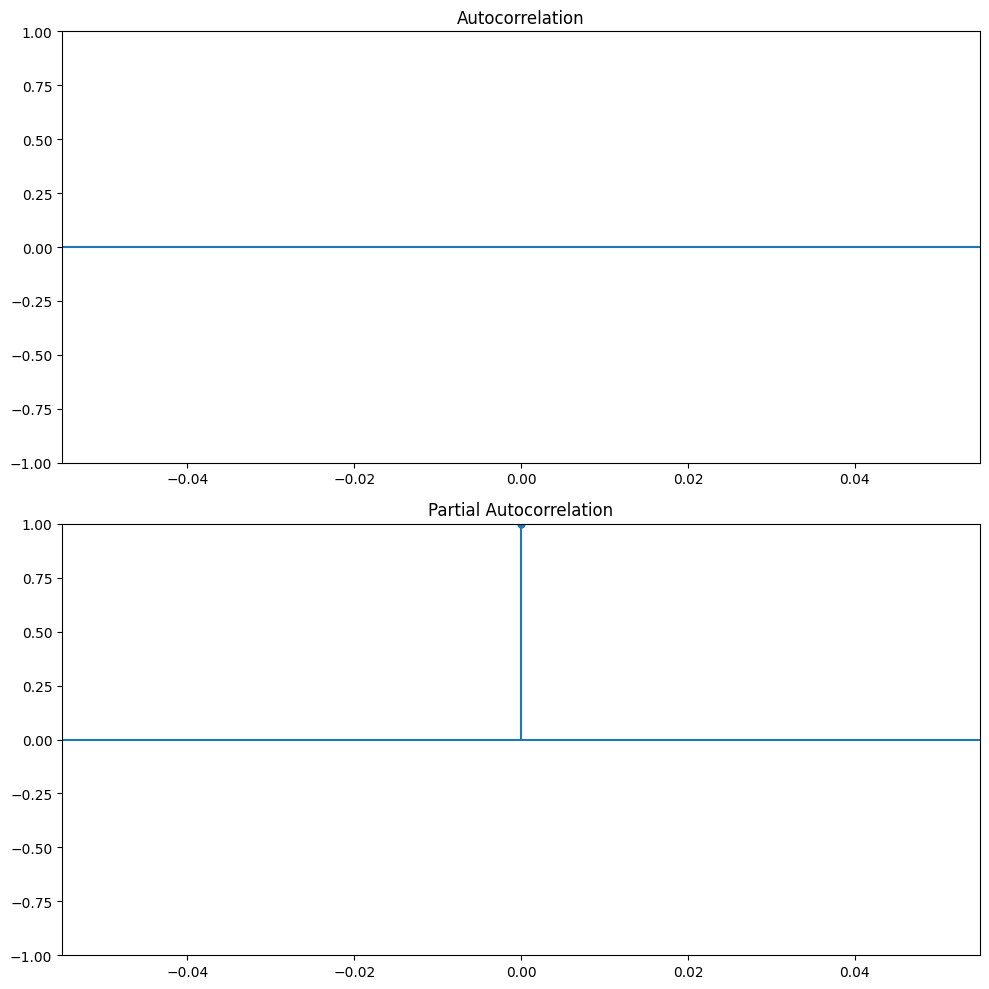

In [28]:
width = 10
height = 5

f, ax = plt.subplots(nrows=2, ncols=1, figsize=(width, 2*height))
plot_acf(df_merged_detrended['TotSales_diff'],lags=36, ax=ax[0], alpha=0.05 )
plot_pacf(df_merged_detrended['TotSales_diff'],lags=36, ax=ax[1], alpha=0.05, method="ywm")

# ax[1].annotate('Strong correlation at lag = 1', xy=(1, 0.6),  xycoords='data',
#             xytext=(0.17, 0.75), textcoords='axes fraction',
#             arrowprops=dict(color='red', shrink=0.05, width=1))

plt.tight_layout()
plt.show()

## 1.4 Rolling and Lagged features

In [29]:
df_merged_detrended['rolling_mean_3m'] = df_merged_detrended['TotSales_diff'].rolling(window=3).mean()
df_merged_detrended['rolling_mean_6m'] = df_merged_detrended['TotSales_diff'].rolling(window=6).mean()
df_merged_detrended['rolling_mean_12m'] = df_merged_detrended['TotSales_diff'].rolling(window=12).mean()
df_merged_detrended['rolling_std_12m'] = df_merged_detrended['TotSales_diff'].rolling(window=12).std()

df_merged_detrended['lag_1m'] = df_merged_detrended['TotSales_diff'].shift(1)
df_merged_detrended['lag_2m'] = df_merged_detrended['TotSales_diff'].shift(2)
df_merged_detrended['lag_3m'] = df_merged_detrended['TotSales_diff'].shift(3)
df_merged_detrended['lag_12m'] = df_merged_detrended['TotSales_diff'].shift(12)


cose da fare: 
- fare variabili rolling e lagged
- fare modello con:

        - VAR

        - VARMAX

        - SARIMAX

        - eventualmente con LGBM

- cerca di capire come usare la uncertainty coefficient
- chiedi consiglio su come dovresti fare la PCA

https://medium.com/@soubhikkhankary28/multivariate-time-series-using-var-model-efa215371738

# Uncertainty coefficient

In [30]:
def _validate_and_crosstab(x, y):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if df.empty:
        return None
    pxy_table = pd.crosstab(df["x"], df["y"], normalize='all')
    if pxy_table.size == 0 or pxy_table.values.sum() == 0:
        return None
    return pxy_table.to_numpy(dtype=float)
 
def uncertainty_coefficients(x,y,base = 2):
    """Compute Theil's U between two categorical variables.
   
    Params
    ------
    x, y: array-like (categorical, string, or discrete)
          Variables of equal length. NaN pairs are dropped pairwise.
    base: float, optional (default = 2)
          Logarithm base for the entropy.
         
    Returns
    -------
    dict with keys:
        - 'U_X_given_Y' : U(X | Y) = I(X;Y) / H(X)
        - 'U_Y_given_X' : U(Y | X) = I(X;Y) / H(Y)
        - 'U_symmetric' : 2 * I(X;Y) / (H(X) + H(Y))   (0 if both entropies are 0)
 
    Notes
    -----
    I(X;Y) = H(X) + H(Y) - H(X,Y)
    H(X|Y) = H(X,Y) - H(Y)
    When H(X)=0 (or H(Y)=0), the corresponding asymmetric U is defined as 0.0.
    """
    pxy = _validate_and_crosstab(x, y)
    if pxy is None:
        return {"U_X_given_Y": np.nan, "U_Y_given_X": np.nan, "U_symmetric": np.nan}
   
    px = pxy.sum(axis = 1)
    py = pxy.sum(axis = 0)
   
    Hx = entropy(px, base=base)
    Hy = entropy(py, base=base)
    Hxy = entropy(pxy.ravel(), base=base)
   
    Ixy = Hx + Hy - Hxy
   
    U_x_given_y = 0.0 if np.isclose(Hx,0.0) else Ixy / Hx
    U_y_given_x = 0.0 if np.isclose(Hy,0.0) else Ixy / Hy
   
    den = Hx + Hy
    U_sym = 0.0 if np.isclose(den, 0.0) else (2.0 * Ixy) / den
   
    return {"U_X_given_Y": U_x_given_y, "U_Y_given_X": U_y_given_x, "U_symmetric": U_sym}
 
def pairwise_uncertainty(df, cols = None, base=2, symmetric=False):
    """Compute a pairwise matrix of Theil's uncertainty coefficients for a DataFrame.
   
    Params
    ------
        df: pandas.DataFrame
            The data. Non-categorical columns are allowed.
        cols: list-like or None
              Subset of cols to include. Defaults to all columns.
        base: float
              Entropy base (2 for bits)
        symmetric: bool
                   If True, returns the symmetric coefficient, else returns
                   U(X|Y) with rows = X, cols = Y.
   
    Returns
    -------
    pandas.DataFrame
        Matrix of uncertainty coeffs.
    """
    if cols is None:
        cols = list(df.columns)
   
    cols = list(cols)
    res = pd.DataFrame(index=cols, columns=cols, dtype=float)
   
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                res.iloc[i,j] = 1
                continue
            coeffs = uncertainty_coefficients(df[c1], df[c2], base=base)
            res.iloc[i,j] = coeffs["U_symmetric"] if symmetric else coeffs["U_X_given_Y"]
   
    return res
 

In [31]:
cols_coeff = ['Anno', 'Mese', 'date', 'GDPGrowth', 'WorkingDays', 'fixed_term_diff',
       'permanent_diff', 'workforce_diff', 'inactives_diff',
       'employment_rate_diff', 'youth_employment_rate_diff',
       'activity_rate_diff', 'unemployment_rate_diff',
       'industry_production_prices_diff', 'companies_trust',
       'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
       'diesel_heatining_price_diff', 'covid_period', 'ukraine_war',
       'TotSales_diff', 'TotSales']

In [32]:
df_to_corr = df_merged_detrended[df_merged_detrended['date']<= '2025/07/01']
df_to_corr = df_to_corr[cols_coeff]

df_unc_corr = pairwise_uncertainty(df_to_corr)


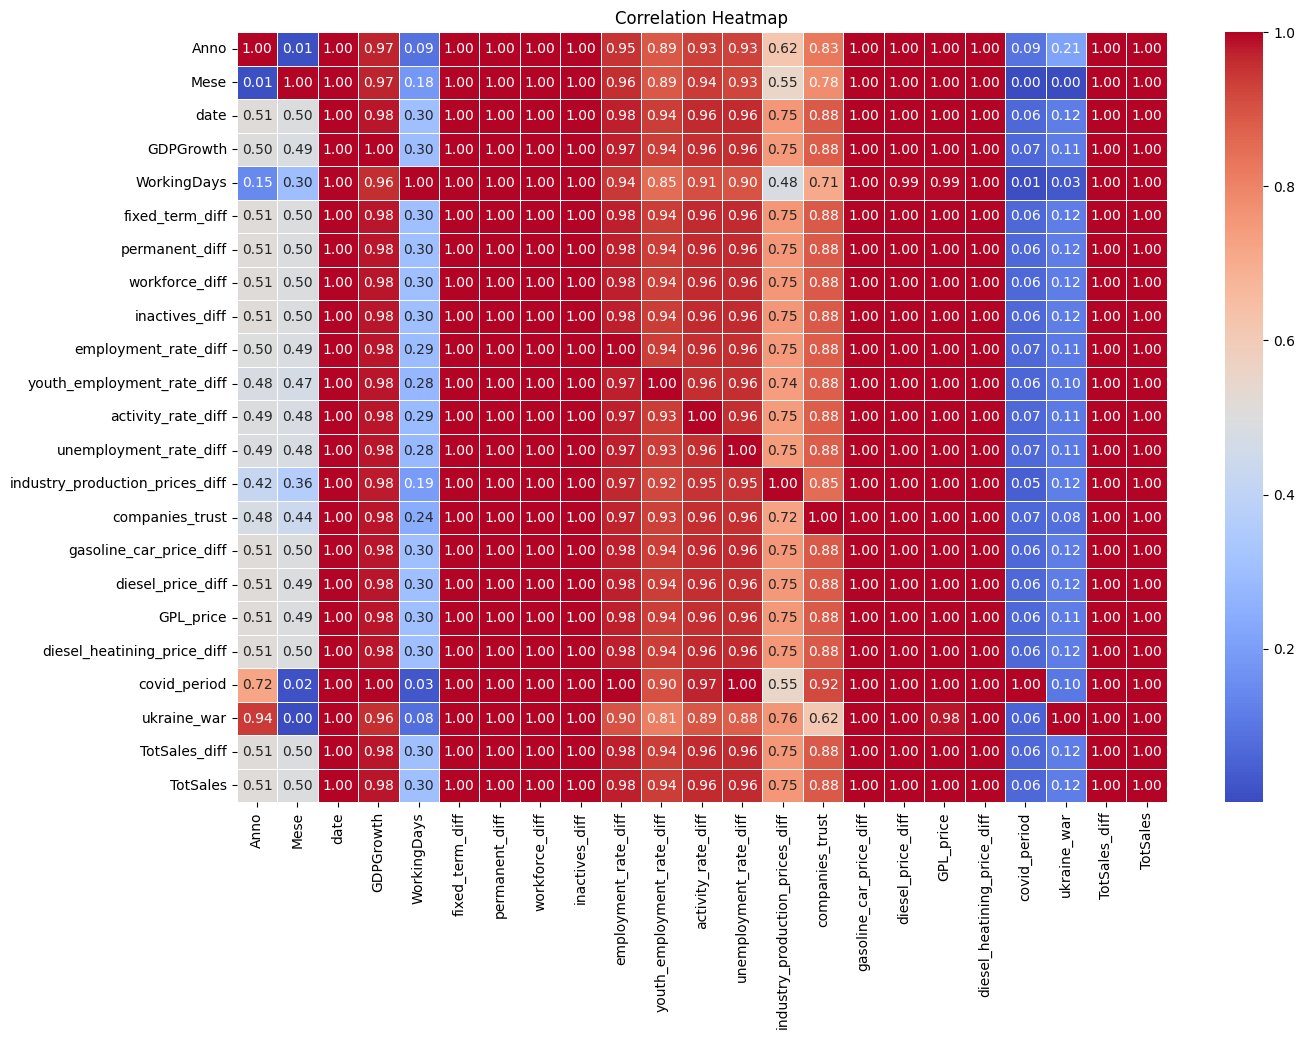

In [33]:

plt.figure(figsize=(15,10))
sns.heatmap(df_unc_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

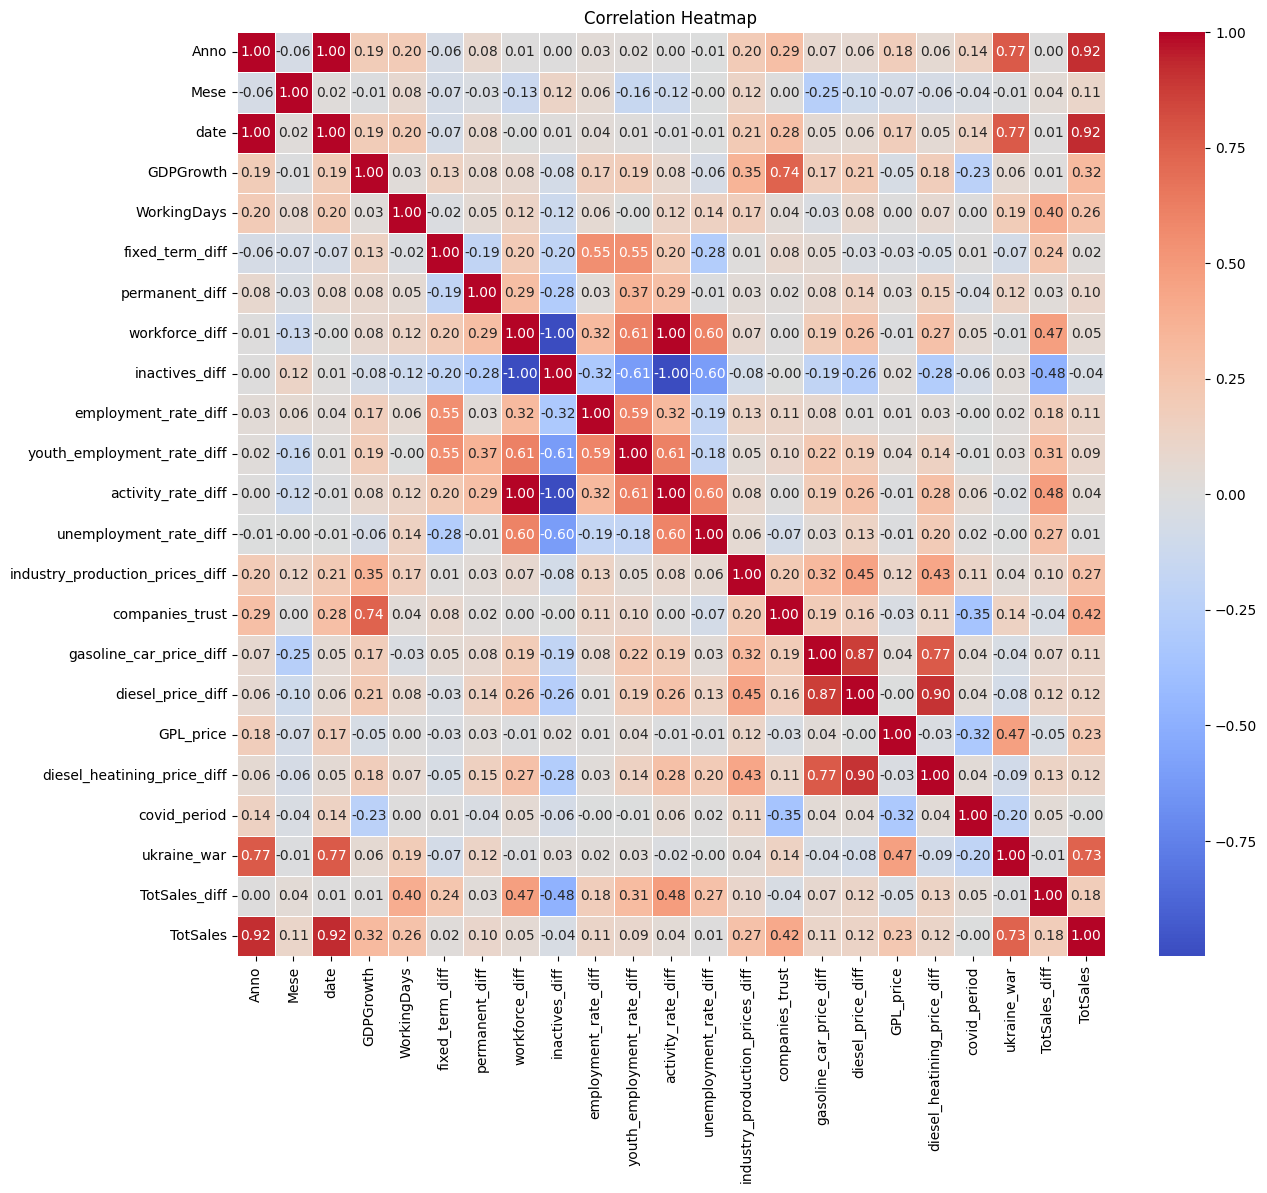

In [34]:
matrix = df_to_corr.corr(method = 'spearman')

plt.figure(figsize=(14,12))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# PCA

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [36]:
df_merged_detrended = df_merged_detrended.iloc[13:] # questo serve a togliere le prime 13 righe che hanno dei valori NUll

In [37]:
X_labour_market = df_merged_detrended[['fixed_term_diff','permanent_diff', 'workforce_diff', 'inactives_diff',
                                            'employment_rate_diff', 'youth_employment_rate_diff',
                                            'activity_rate_diff', 'unemployment_rate_diff']]

X_price_energy = df_merged_detrended[[ 'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price', 'diesel_heatining_price_diff']]

X_macroeconomic_variables = df_merged_detrended[['GDPGrowth',  'industry_production_prices_diff', 'companies_trust' ]]

scaler = StandardScaler()
X_labour_market_scaled = scaler.fit_transform(X_labour_market)
X_price_energy_scaled = scaler.fit_transform(X_price_energy)
X_macroeconomic_variables_scaled = scaler.fit_transform(X_macroeconomic_variables)

In [38]:
pca = PCA(n_components=2)
df_merged_detrended[['PCA_labour_market_1', 'PCA_labour_market_2']] = pca.fit_transform(X_labour_market_scaled)
df_merged_detrended[['PCA_price_energy_1', 'PCA_price_energy_2']] = pca.fit_transform(X_price_energy)
df_merged_detrended[['PCA_macroeconomic_variables_1', 'PCA_macroeconomic_variables_2']] = pca.fit_transform(X_macroeconomic_variables)

In [39]:
pca_all = PCA()

all_columns = ['GDPGrowth', 'WorkingDays', 'fixed_term_diff',
                'permanent_diff', 'workforce_diff', 'inactives_diff',
                'employment_rate_diff', 'youth_employment_rate_diff',
                'activity_rate_diff', 'unemployment_rate_diff',
                'industry_production_prices_diff', 'companies_trust',
                'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
                'diesel_heatining_price_diff', 'covid_period', 'ukraine_war',
                ]

df_merged_detrended[all_columns]

all_columns_scaled = scaler.fit_transform(df_merged_detrended[all_columns])

# df_merged_detrended[['PCA_labour_market_1', 'PCA_labour_market_2']] = 
df_temp = pca_all.fit_transform(all_columns_scaled)



In [40]:
pca_all.explained_variance_ratio_

array([2.70834865e-01, 1.38540495e-01, 1.25014509e-01, 1.03416946e-01,
       7.50693862e-02, 6.11146647e-02, 5.58304308e-02, 5.00434281e-02,
       3.44885301e-02, 2.22927246e-02, 1.85943847e-02, 1.71611646e-02,
       1.26893244e-02, 1.21340114e-02, 2.66699911e-03, 7.01197248e-05,
       3.35411638e-05, 4.47456792e-06])

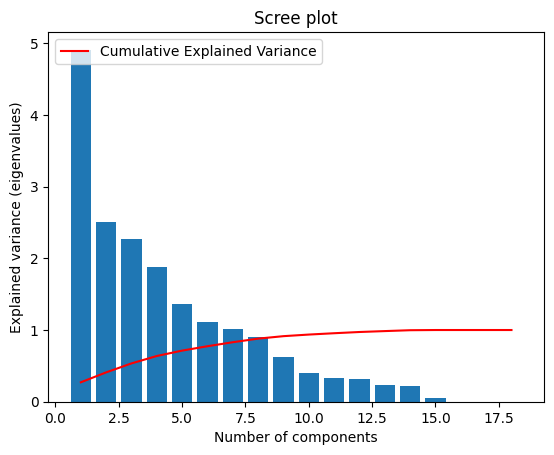

In [41]:
exp_var_cumul = np.cumsum(pca_all.explained_variance_ratio_)
plt.bar(range(1, len(pca_all.explained_variance_)+1), pca_all.explained_variance_)
plt.plot(range(1, len(pca_all.explained_variance_)+1), exp_var_cumul, c='red', label='Cumulative Explained Variance')
plt.legend(loc='upper left')
plt.xlabel('Number of components')
plt.ylabel('Explained variance (eigenvalues)')
plt.title('Scree plot')
plt.show()

#il grafico mostra che il numero idela di componeneti da tenere è tra 7 e 8, perché dopo la curva rossa tende ad appiattirsi
 

In [42]:
df_merged_detrended.columns

Index(['Anno', 'Mese', 'date', 'GDPGrowth', 'WorkingDays', 'fixed_term_diff',
       'permanent_diff', 'workforce_diff', 'inactives_diff',
       'employment_rate_diff', 'youth_employment_rate_diff',
       'activity_rate_diff', 'unemployment_rate_diff',
       'industry_production_prices_diff', 'companies_trust',
       'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
       'diesel_heatining_price_diff', 'covid_period', 'ukraine_war',
       'TotSales_diff', 'TotSales', 'rolling_mean_3m', 'rolling_mean_6m',
       'rolling_mean_12m', 'rolling_std_12m', 'lag_1m', 'lag_2m', 'lag_3m',
       'lag_12m', 'PCA_labour_market_1', 'PCA_labour_market_2',
       'PCA_price_energy_1', 'PCA_price_energy_2',
       'PCA_macroeconomic_variables_1', 'PCA_macroeconomic_variables_2'],
      dtype='object')

In [43]:
df_merged_detrended = df_merged_detrended[['date','Anno', 'Mese',  'GDPGrowth', 'WorkingDays', 'fixed_term_diff',
                                            'permanent_diff', 'workforce_diff', 'inactives_diff',
                                            'employment_rate_diff', 'youth_employment_rate_diff',
                                            'activity_rate_diff', 'unemployment_rate_diff',
                                            'industry_production_prices_diff', 'companies_trust',
                                            'gasoline_car_price_diff', 'diesel_price_diff', 'GPL_price',
                                            'diesel_heatining_price_diff', 'covid_period', 'ukraine_war', 
                                            'rolling_mean_3m', 'rolling_mean_6m', 'rolling_mean_12m', 'rolling_std_12m', 
                                            'lag_1m', 'lag_2m', 'lag_3m', 'lag_12m', 
                                            'PCA_labour_market_1', 'PCA_labour_market_2',
                                            'PCA_price_energy_1', 'PCA_price_energy_2',
                                            'PCA_macroeconomic_variables_1', 'PCA_macroeconomic_variables_2',
                                            'TotSales_diff', 'TotSales']]

In [44]:
set(df_merged_detrended.columns.tolist()) -set(df_merged.columns.tolist())

{'PCA_labour_market_1',
 'PCA_labour_market_2',
 'PCA_macroeconomic_variables_1',
 'PCA_macroeconomic_variables_2',
 'PCA_price_energy_1',
 'PCA_price_energy_2',
 'lag_12m',
 'lag_1m',
 'lag_2m',
 'lag_3m',
 'rolling_mean_12m',
 'rolling_mean_3m',
 'rolling_mean_6m',
 'rolling_std_12m'}

In [45]:
df_merged.to_csv("dataset_FINAL.csv")

In [46]:
df_mising_cols = df_merged_detrended[['date','PCA_labour_market_1', 'PCA_labour_market_2',  'PCA_macroeconomic_variables_1', 
                                      'PCA_macroeconomic_variables_2', 'PCA_price_energy_1', 'PCA_price_energy_2', 
                                      'lag_12m', 'lag_1m', 'lag_2m', 'lag_3m', 'rolling_mean_12m', 
                                      'rolling_mean_3m',  'rolling_mean_6m', 'rolling_std_12m']]

In [48]:
df_final = df_merged.merge(df_mising_cols, how ='inner', on = 'date')
df_final.to_csv("dataset_FINAL_all_variables.csv", index=False)

# BACK UP

## 1.2 Correlation

In [10]:
df_to_corr = df_merged[df_merged['date']<= '2025/07/01']
df_to_corr.drop(columns = 'date', inplace= True)

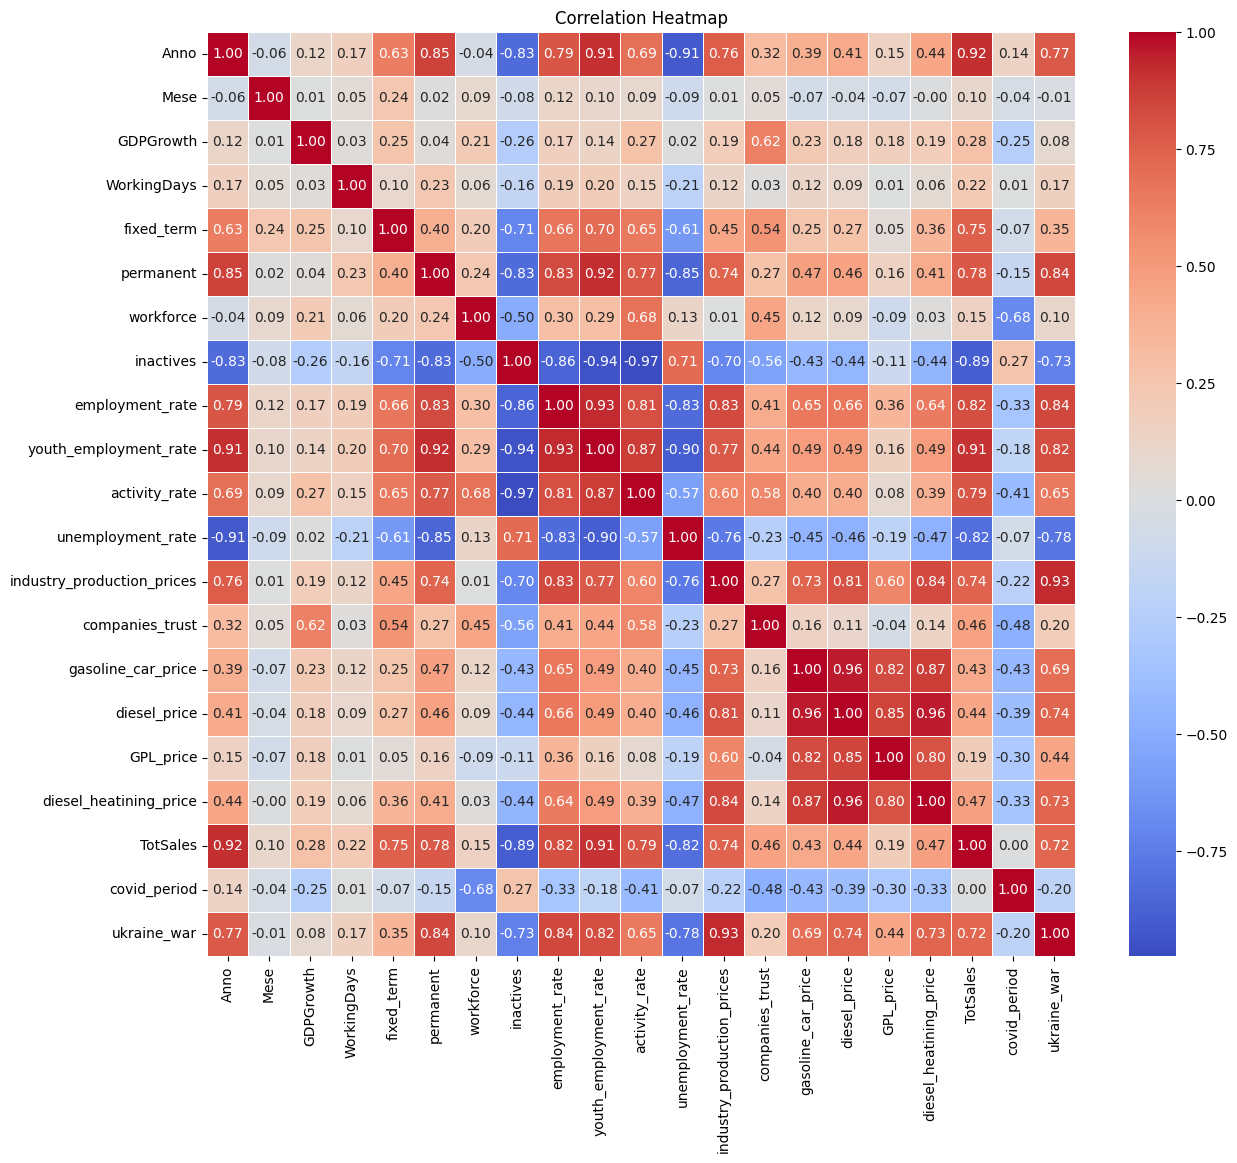

In [11]:
matrix = df_to_corr.corr()

plt.figure(figsize=(14,12))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
matrix[matrix.TotSales >= 0.4]['TotSales']

Anno                          0.916896
fixed_term                    0.752607
permanent                     0.783443
employment_rate               0.815897
youth_employment_rate         0.907283
activity_rate                 0.789945
industry_production_prices    0.742463
companies_trust               0.460310
gasoline_car_price            0.427178
diesel_price                  0.440608
diesel_heatining_price        0.469574
TotSales                      1.000000
ukraine_war                   0.724098
Name: TotSales, dtype: float64

In [12]:
def _validate_and_crosstab(x, y):
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if df.empty:
        return None
    pxy_table = pd.crosstab(df["x"], df["y"], normalize='all')
    if pxy_table.size == 0 or pxy_table.values.sum() == 0:
        return None
    return pxy_table.to_numpy(dtype=float)
 
def uncertainty_coefficients(x,y,base = 2):
    """Compute Theil's U between two categorical variables.
   
    Params
    ------
    x, y: array-like (categorical, string, or discrete)
          Variables of equal length. NaN pairs are dropped pairwise.
    base: float, optional (default = 2)
          Logarithm base for the entropy.
         
    Returns
    -------
    dict with keys:
        - 'U_X_given_Y' : U(X | Y) = I(X;Y) / H(X)
        - 'U_Y_given_X' : U(Y | X) = I(X;Y) / H(Y)
        - 'U_symmetric' : 2 * I(X;Y) / (H(X) + H(Y))   (0 if both entropies are 0)
 
    Notes
    -----
    I(X;Y) = H(X) + H(Y) - H(X,Y)
    H(X|Y) = H(X,Y) - H(Y)
    When H(X)=0 (or H(Y)=0), the corresponding asymmetric U is defined as 0.0.
    """
    pxy = _validate_and_crosstab(x, y)
    if pxy is None:
        return {"U_X_given_Y": np.nan, "U_Y_given_X": np.nan, "U_symmetric": np.nan}
   
    px = pxy.sum(axis = 1)
    py = pxy.sum(axis = 0)
   
    Hx = entropy(px, base=base)
    Hy = entropy(py, base=base)
    Hxy = entropy(pxy.ravel(), base=base)
   
    Ixy = Hx + Hy - Hxy
   
    U_x_given_y = 0.0 if np.isclose(Hx,0.0) else Ixy / Hx
    U_y_given_x = 0.0 if np.isclose(Hy,0.0) else Ixy / Hy
   
    den = Hx + Hy
    U_sym = 0.0 if np.isclose(den, 0.0) else (2.0 * Ixy) / den
   
    return {"U_X_given_Y": U_x_given_y, "U_Y_given_X": U_y_given_x, "U_symmetric": U_sym}
 
def pairwise_uncertainty(df, cols = None, base=2, symmetric=False):
    """Compute a pairwise matrix of Theil's uncertainty coefficients for a DataFrame.
   
    Params
    ------
        df: pandas.DataFrame
            The data. Non-categorical columns are allowed.
        cols: list-like or None
              Subset of cols to include. Defaults to all columns.
        base: float
              Entropy base (2 for bits)
        symmetric: bool
                   If True, returns the symmetric coefficient, else returns
                   U(X|Y) with rows = X, cols = Y.
   
    Returns
    -------
    pandas.DataFrame
        Matrix of uncertainty coeffs.
    """
    if cols is None:
        cols = list(df.columns)
   
    cols = list(cols)
    res = pd.DataFrame(index=cols, columns=cols, dtype=float)
   
    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                res.iloc[i,j] = 1
                continue
            coeffs = uncertainty_coefficients(df[c1], df[c2], base=base)
            res.iloc[i,j] = coeffs["U_symmetric"] if symmetric else coeffs["U_X_given_Y"]
   
    return res
 

In [13]:
df_unc_corr = pairwise_uncertainty(df_to_corr)
df_unc_corr

,Anno,Mese,GDPGrowth,WorkingDays,fixed_term,permanent,workforce,inactives,employment_rate,youth_employment_rate,...,unemployment_rate,industry_production_prices,companies_trust,gasoline_car_price,diesel_price,GPL_price,diesel_heatining_price,TotSales,covid_period,ukraine_war
Anno,1.000000,0.009469,0.972160,0.087370,1.0,1.0,1.0,1.0,0.967691,0.982050,...,0.962746,0.902417,0.856553,1.0,1.0,0.996410,1.0,1.0,0.091439,0.214660
Mese,0.009748,1.000000,0.971340,0.183446,1.0,1.0,1.0,1.0,0.951955,0.977825,...,0.954256,0.809680,0.798838,1.0,1.0,0.996304,1.0,1.0,0.002164,0.001050
GDPGrowth,0.503588,0.488756,1.000000,0.295430,1.0,1.0,1.0,1.0,0.972106,0.988842,...,0.973263,0.902376,0.893009,1.0,1.0,0.998140,1.0,1.0,0.065552,0.113325
WorkingDays,0.146947,0.299703,0.959215,1.000000,1.0,1.0,1.0,1.0,0.939621,0.975848,...,0.931304,0.787953,0.745924,1.0,1.0,0.993962,1.0,1.0,0.005431,0.030604
fixed_term,0.509710,0.495116,0.983980,0.303057,1.0,1.0,1.0,1.0,0.972553,0.989021,...,0.973692,0.903940,0.894737,1.0,1.0,0.998170,1.0,1.0,0.064502,0.116551
permanent,0.509710,0.495116,0.983980,0.303057,1.0,1.0,1.0,1.0,0.972553,0.989021,...,0.973692,0.903940,0.894737,1.0,1.0,0.998170,1.0,1.0,0.064502,0.116551
workforce,0.509710,0.495116,0.983980,0.303057,1.0,1.0,1.0,1.0,0.972553,0.989021,...,0.973692,0.903940,0.894737,1.0,1.0,0.998170,1.0,1.0,0.064502,0.116551
inactives,0.509710,0.495116,0.983980,0.303057,1.0,1.0,1.0,1.0,0.972553,0.989021,...,0.973692,0.903940,0.894737,1.0,1.0,0.998170,1.0,1.0,0.064502,0.116551
employment_rate,0.507162,0.484630,0.983528,0.292795,1.0,1.0,1.0,1.0,1.000000,0.988711,...,0.972949,0.903110,0.891742,1.0,1.0,0.998119,1.0,1.0,0.060678,0.119840
youth_employment_rate,0.506118,0.489511,0.983802,0.299021,1.0,1.0,1.0,1.0,0.972248,1.000000,...,0.973400,0.902873,0.893559,1.0,1.0,0.998150,1.0,1.0,0.065218,0.117845


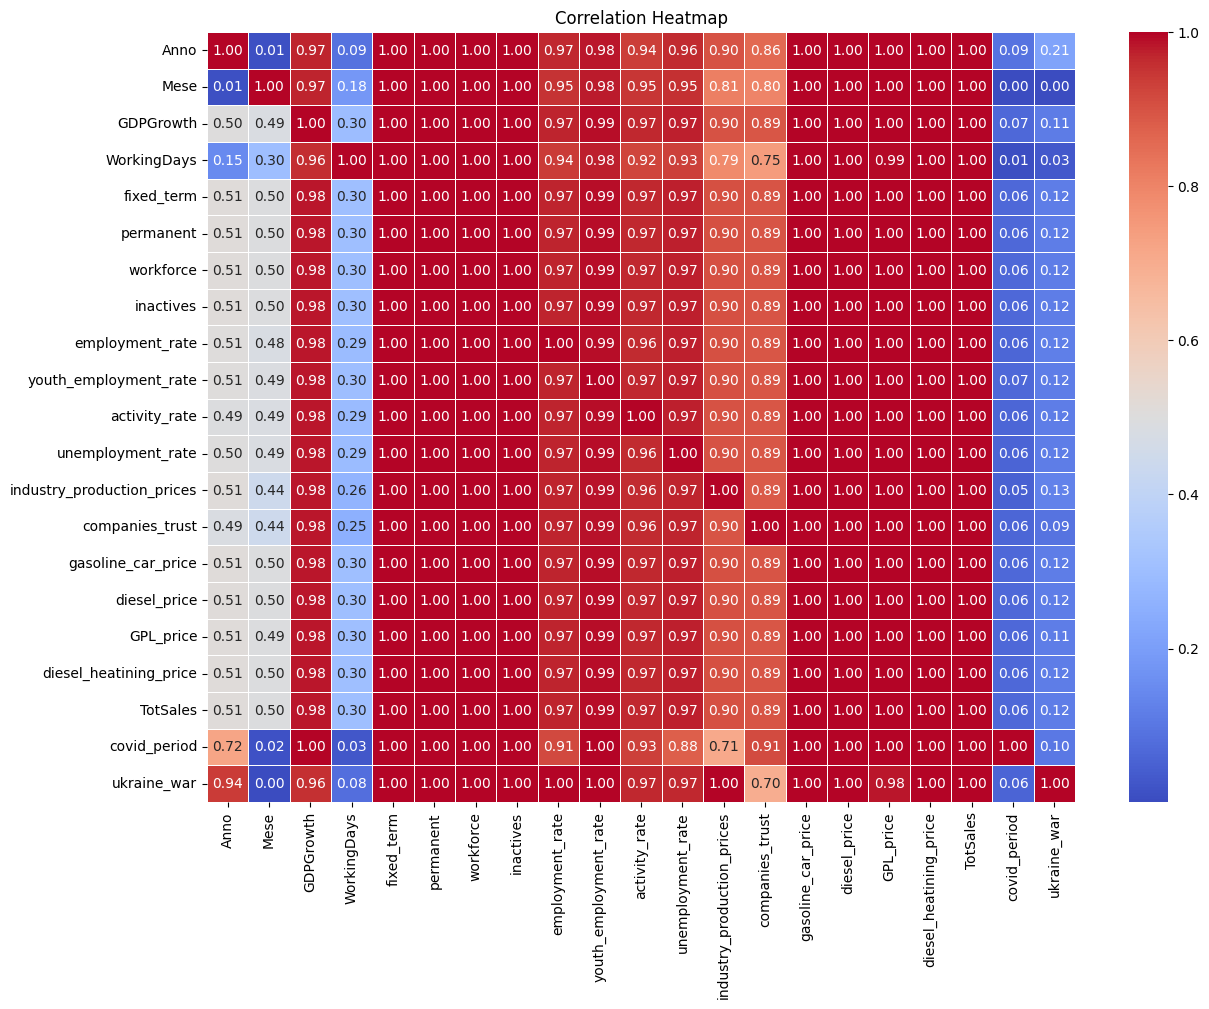

In [15]:

plt.figure(figsize=(14,10))
sns.heatmap(df_unc_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# Cose da fare: 

- PCA per le variabili tra loro correlate (es. youth_unemployment e unemployment rate; i vari prezzi dei carburanti)

- selezionare le variabili che sono più correlate rispetto a TotSales (coeff. corr >= 0.40)

- successivamente dovrai fare un po' div ariabili rolling, decomposizione, individuare quali variabili sono stazionarie 

- bisognare predirre le variabili dei mesi futuri usando degli arima --> vedi appunti Tony
